# Opposition-Aware Visual–Semantic OaSC

**Base method:** *Recognizing Unseen States of Unknown Objects by Leveraging Knowledge Graphs* (WACV 2025)

This is the cleaned notebook for the final project experiments, presentation figures, and paper writing.

## Final pipeline

1. **Original OaSC:** released ResNet-101 + Tr-GCN state classifiers.
2. **CLIP-guided KG refinement:** fuse KG random-walk relevance with CLIP text semantics.
3. **Ambiguity-adaptive fusion:** noisy/dense state neighborhoods receive stronger semantic guidance.
4. **OCGG — Opposition-Aware Contrastive Graph Gating:** use target-vs-opposite semantic evidence to suppress contradictory KG neighbors.
5. **OLRP — Opposition-Aware Local Region Pooling:** recover local spatial state evidence from the final ResNet feature map and contrast it with the opposite state.

### Fixed final OLRP configuration

- Region size: **3 × 3**
- Top regions: **3**
- Local residual weight: **α = 0.10**
- No additional backbone training.

## Recorded OSDD results from the completed run

| Method | Best HM | Max Unseen | AUC |
|---|---:|---:|---:|
| Original OaSC | 50.07 | 64.82 | 40.16 |
| Fixed CLIP KG | 50.24 | 66.16 | 40.76 |
| Ambiguity-Adaptive CLIP KG | 50.56 | 65.74 | 40.63 |
| OCGG | 50.58 | 66.41 | 40.96 |
| OCGG + Local Pooling | 51.03 | 66.50 | **41.66** |
| **OCGG + OLRP** | **51.57** | **66.67** | 41.50 |

Compared with original OaSC, the final OCGG+OLRP model improves **HM by +1.50 pp**, **Max Unseen by +1.85 pp**, and **AUC by +1.34**.

> Keep failed exploratory branches (SAM, CLIP patch grounding, residual adapters, routers, description fusion, etc.) out of the main notebook. They can be mentioned briefly as negative experiments only if needed.


## 1. Environment and official OaSC release

Run on Kaggle with **GPU** and **Internet ON**. The notebook downloads the official OaSC repository and released model/data package.


In [10]:
# Cell 1 — Kaggle / GPU sanity check
import os, sys, platform, subprocess
from pathlib import Path

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())

try:
    import torch, torchvision
    print('PyTorch:', torch.__version__)
    print('Torchvision:', torchvision.__version__)
    print('CUDA available:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
except Exception as e:
    print('Torch import error:', repr(e))

if not torch.cuda.is_available():
    print('\nWARNING: GPU is not enabled. Kaggle -> Settings -> Accelerator -> GPU.')


Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
%pip install -q gdown transformers


In [11]:
# Cell 3 — Clone the official repository
from pathlib import Path
import subprocess, shutil, os

WORK = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
REPO_ROOT = WORK / 'OaSC_official'
METHOD_DIR = REPO_ROOT / 'OaSC'
SRC_DIR = METHOD_DIR / 'src'

if not REPO_ROOT.exists():
    subprocess.run([
        'git', 'clone', '--depth', '1',
        'https://github.com/philipposg/OaSC.git',
        str(REPO_ROOT)
    ], check=True)
else:
    print('Repository already exists:', REPO_ROOT)

commit = subprocess.check_output(['git', '-C', str(REPO_ROOT), 'rev-parse', 'HEAD'], text=True).strip()
print('Repository:', REPO_ROOT)
print('Commit:', commit)
print('OaSC method dir:', METHOD_DIR)

required = [
    SRC_DIR / 'test.py',
    SRC_DIR / 'finetune.py',
    SRC_DIR / 'train_gnn.py',
    SRC_DIR / 'download_data.sh',
]
for p in required:
    print(('OK  ' if p.exists() else 'MISS'), p.relative_to(REPO_ROOT))

assert all(p.exists() for p in required), 'The full official repo was not cloned correctly.'


Repository already exists: /kaggle/working/OaSC_official
Repository: /kaggle/working/OaSC_official
Commit: b031a50f3b93aed1fd45def6319b117fc5eaf8b6
OaSC method dir: /kaggle/working/OaSC_official/OaSC
OK   OaSC/src/test.py
OK   OaSC/src/finetune.py
OK   OaSC/src/train_gnn.py
OK   OaSC/src/download_data.sh


In [12]:
# Cell 4 — Download OaSC_material.tar.gz (or reuse an uploaded copy)
import gdown, glob, shutil
from pathlib import Path

FILE_ID = '1i-jaMPKoBOmBncKBQ3qpsGQ9pLWgwRbz'
ARCHIVE = WORK / 'OaSC_material.tar.gz'

# Optional offline/manual fallback:
# If you already uploaded OaSC_material.tar.gz as a Kaggle Dataset,
# this searches /kaggle/input and uses it instead of downloading again.
manual_candidates = list(Path('/kaggle/input').rglob('OaSC_material.tar.gz')) if Path('/kaggle/input').exists() else []

if ARCHIVE.exists() and ARCHIVE.stat().st_size > 1_000_000:
    print('Using existing archive:', ARCHIVE)
elif manual_candidates:
    print('Using uploaded Kaggle archive:', manual_candidates[0])
    shutil.copy2(manual_candidates[0], ARCHIVE)
else:
    print('Downloading released OaSC material from the authors\' Google Drive...')
    out = gdown.download(id=FILE_ID, output=str(ARCHIVE), quiet=False)
    if out is None:
        raise RuntimeError(
            'Download failed. Make sure Kaggle Internet is ON, or upload '
            'OaSC_material.tar.gz as a Kaggle Dataset and rerun this cell.'
        )

print('Archive:', ARCHIVE)
print('Size: %.2f GB' % (ARCHIVE.stat().st_size / 1024**3))


Using existing archive: /kaggle/working/OaSC_material.tar.gz
Archive: /kaggle/working/OaSC_material.tar.gz
Size: 1.21 GB


In [13]:
# Cell 5 — Extract the nested release archives into the locations expected by OaSC
import tarfile, os, shutil
from pathlib import Path

STAGING = WORK / 'oasc_release_staging'
STAGING.mkdir(parents=True, exist_ok=True)

marker = METHOD_DIR / '.oasc_material_extracted'

if marker.exists():
    print('Release material already extracted.')
else:
    print('Extracting outer archive...')
    with tarfile.open(ARCHIVE, 'r:gz') as tf:
        tf.extractall(STAGING)

    # Locate inner archives even if the outer archive adds one directory level.
    inner = {p.name: p for p in STAGING.rglob('*.tar.gz')}
    print('Inner archives found:', sorted(inner))

    def extract(name, destination):
        if name not in inner:
            print(f'WARNING: {name} not found; skipping.')
            return
        destination = Path(destination)
        destination.mkdir(parents=True, exist_ok=True)
        print(f'Extracting {name} -> {destination}')
        with tarfile.open(inner[name], 'r:gz') as tf:
            tf.extractall(destination)

    # Matches the intent of the authors' download_data.sh
    extract('datasets.tar.gz', METHOD_DIR)
    extract('embeddings.tar.gz', METHOD_DIR)
    extract('saved_checkpoints.tar.gz', METHOD_DIR)
    extract('data.tar.gz', SRC_DIR)

    marker.write_text('ok')

print('\nChecking expected OSDD files...')
paths = {
    'OSDD train': METHOD_DIR / 'datasets/osdd/train',
    'OSDD test': METHOD_DIR / 'datasets/osdd/test',
    'OaSC state embeddings': METHOD_DIR / 'embeddings/osdd_emb.pred',
    'Fine-tuned ResNet-101': METHOD_DIR / 'saved_checkpoints/osdd/finetuned_weights.pth',
}
for name, p in paths.items():
    print(f'{name:25s}:', 'OK' if p.exists() else 'MISSING', p)

missing = [name for name, p in paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError('Missing release material: ' + ', '.join(missing))


Release material already extracted.

Checking expected OSDD files...
OSDD train               : OK /kaggle/working/OaSC_official/OaSC/datasets/osdd/train
OSDD test                : OK /kaggle/working/OaSC_official/OaSC/datasets/osdd/test
OaSC state embeddings    : OK /kaggle/working/OaSC_official/OaSC/embeddings/osdd_emb.pred
Fine-tuned ResNet-101    : OK /kaggle/working/OaSC_official/OaSC/saved_checkpoints/osdd/finetuned_weights.pth


## 2. Load the released OaSC model and OSDD

The released state vectors are 2049-dimensional: **2048 classifier weights + 1 bias**.  
OSDD uses four unseen states in this protocol: **empty, open, folded, filled**.


In [14]:
# Cell 6 — Load and inspect the Tr-GCN-generated OSDD state vectors
import torch

EMB_PATH = METHOD_DIR / 'embeddings/osdd_emb.pred'
GRAPH_TYPE = 'conceptnet_wordnet_hop1_thresh_10'

# PyTorch >=2.6 changed torch.load's default behavior. These are trusted files
# downloaded from the paper authors' release, so we explicitly allow the old format.
def torch_load_compat(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:  # older PyTorch
        return torch.load(path, map_location=map_location)

emb_file = torch_load_compat(EMB_PATH)
print('Available graph keys:')
for k in emb_file.keys():
    print('  ', k)

assert GRAPH_TYPE in emb_file, f'{GRAPH_TYPE} not found in embedding file.'
state_vectors = emb_file[GRAPH_TYPE].float()
print('\nSelected graph:', GRAPH_TYPE)
print('State-vector tensor shape:', tuple(state_vectors.shape))
assert state_vectors.ndim == 2 and state_vectors.shape[1] == 2049


Available graph keys:
   osdd2
   osdd_ir_9_graph
   osdd_wordnet_states
   conceptnet_hop2_thresh_10
   wordnet_states_hop2
   conceptnet_hop1_thresh_10
   conceptnet_hop1_thresh_0
   conceptnet_wordnet_hop2_thresh_10
   conceptnet_wordnet_hop1_thresh_0
   conceptnet_wordnet_hop1_thresh_10
   visualgenome_states_hops0
   visualgenome_states_hops1
   visualgenome_hops1
   vg_from_cskg_states_hops0
   vg_from_cskg_states_hops1
   vg_from_cskg_hops1
   cskg_states_hops0
   vg_cn_from_cskg_states_hops0
   vg_cn_wn_from_cskg_states_hops0
   vg_wn_from_cskg_states_hops0
   vg_cn_from_cskg_states_hops1
   vg_cn_wn_from_cskg_states_hops1
   vg_wn_from_cskg_states_hops1
   cn_from_cskg_states_hops0
   cn_wn_from_cskg_states_hops0
   cn_from_cskg_states_hops1
   cn_wn_from_cskg_states_hops1
   cn_from_cskg_states_hops2
   cn_wn_from_cskg_states_hops2
   cn-wk-from-cskg-states-hops0
   vg-cn-wn-wk-from-cskg-states-hops0
   cn-wn-wk-from-cskg-states-hops0
   vg-wk-from-cskg-states-hops0
   cn-wk-

In [15]:
# Cell 7 — Build the OaSC inference model
import torch
import torch.nn as nn
from torchvision.models import resnet101

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_PATH = METHOD_DIR / 'saved_checkpoints/osdd/finetuned_weights.pth'

# Avoid downloading ImageNet weights here: the released fine-tuned checkpoint
# contains the trained backbone weights already.
try:
    cnn = resnet101(weights=None)
except TypeError:
    cnn = resnet101(pretrained=False)

cnn.fc = nn.Identity()
ckpt = torch_load_compat(CKPT_PATH)

# Some checkpoints may be wrapped; the released OaSC checkpoint is normally a state_dict.
if isinstance(ckpt, dict) and 'state_dict' in ckpt and isinstance(ckpt['state_dict'], dict):
    ckpt = ckpt['state_dict']

# Strip DataParallel prefix if present.
ckpt = {k.replace('module.', ''): v for k, v in ckpt.items()}
ckpt.pop('fc.weight', None)
ckpt.pop('fc.bias', None)

missing, unexpected = cnn.load_state_dict(ckpt, strict=False)
print('Missing keys:', missing)
print('Unexpected keys:', unexpected)

cnn = cnn.to(DEVICE).eval()
state_vectors = state_vectors.to(DEVICE)

print('Device:', DEVICE)
print('Visual feature dimension: 2048')
print('Classifier-vector shape:', tuple(state_vectors.shape))


Missing keys: []
Unexpected keys: []
Device: cuda
Visual feature dimension: 2048
Classifier-vector shape: (9, 2049)


In [16]:
# Cell 8 — Dataset + exact OSDD label mapping used by the authors
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

OSDD_CLASSES = [
    'closed', 'containing', 'empty', 'filled', 'folded',
    'open', 'plugged', 'unfolded', 'unplugged'
]
CLASS_TO_GLOBAL = {name: i for i, name in enumerate(OSDD_CLASSES)}

UNSEEN_NAMES = ['empty', 'open', 'folded', 'filled']
UNSEEN_IDS = [CLASS_TO_GLOBAL[x] for x in UNSEEN_NAMES]
SEEN_IDS = [i for i in range(len(OSDD_CLASSES)) if i not in UNSEEN_IDS]

transform = transforms.Compose([
    transforms.Resize([224, 224]),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

TEST_DIR = METHOD_DIR / 'datasets/osdd/test'
test_ds = datasets.ImageFolder(TEST_DIR, transform=transform)

print('ImageFolder classes:', test_ds.classes)
print('Number of test images:', len(test_ds))

unknown_folders = [c for c in test_ds.classes if c not in CLASS_TO_GLOBAL]
assert not unknown_folders, f'Unexpected OSDD class folders: {unknown_folders}'

folder_idx_to_global = {
    folder_idx: CLASS_TO_GLOBAL[class_name]
    for class_name, folder_idx in test_ds.class_to_idx.items()
}

print('Seen states  :', [OSDD_CLASSES[i] for i in SEEN_IDS])
print('Unseen states:', [OSDD_CLASSES[i] for i in UNSEEN_IDS])
print('Folder -> global mapping:', folder_idx_to_global)

test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)


ImageFolder classes: ['closed', 'containing', 'empty', 'filled', 'folded', 'open', 'plugged', 'unfolded', 'unplugged']
Number of test images: 3109
Seen states  : ['closed', 'containing', 'plugged', 'unfolded', 'unplugged']
Unseen states: ['empty', 'open', 'folded', 'filled']
Folder -> global mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8}


In [17]:

# ============================================================
# Cache OSDD test features ONCE
# All graph variants use these exact same visual features.
# ============================================================

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

feature_batches = []
target_batches = []

cnn.eval()

with torch.inference_mode():
    for images, folder_labels in tqdm(test_loader, desc="Caching OSDD test features"):
        images = images.to(DEVICE, non_blocking=True)

        visual = cnn(images)  # [B, 2048]
        visual_aug = torch.cat(
            [visual, torch.ones(visual.shape[0], 1, device=DEVICE)],
            dim=1
        )  # [B, 2049]

        batch_targets = torch.tensor(
            [folder_idx_to_global[int(x)] for x in folder_labels],
            dtype=torch.long
        )

        feature_batches.append(visual_aug.cpu())
        target_batches.append(batch_targets)

cached_test_features_aug = torch.cat(feature_batches, dim=0)
cached_test_targets = torch.cat(target_batches, dim=0)

print("Cached features:", cached_test_features_aug.shape)
print("Cached targets :", cached_test_targets.shape)


Caching OSDD test features:   0%|          | 0/25 [00:00<?, ?it/s]

Cached features: torch.Size([3109, 2049])
Cached targets : torch.Size([3109])


In [19]:

# ============================================================
# Shared GZSL evaluation helpers
# ============================================================

def evaluate_gamma(scores, targets, gamma):
    calibrated = scores.clone()
    calibrated[:, UNSEEN_IDS] += float(gamma)
    pred = calibrated.argmax(dim=1)

    seen_mask = torch.tensor(
        [int(y) in SEEN_IDS for y in targets],
        dtype=torch.bool
    )
    unseen_mask = ~seen_mask

    seen_acc = (pred[seen_mask] == targets[seen_mask]).float().mean().item()
    unseen_acc = (pred[unseen_mask] == targets[unseen_mask]).float().mean().item()
    hm = 0.0 if (seen_acc + unseen_acc) == 0 else (
        2 * seen_acc * unseen_acc / (seen_acc + unseen_acc)
    )
    total_acc = (pred == targets).float().mean().item()

    return total_acc, seen_acc, unseen_acc, hm


gammas = np.arange(-5.0, 15.125, 0.5)


def evaluate_score_matrix(score_matrix, targets, method_name):
    rows = []

    for gamma in gammas:
        total, seen, unseen, hm = evaluate_gamma(
            score_matrix,
            targets,
            gamma
        )
        rows.append({
            "gamma": gamma,
            "total_acc": total,
            "seen_acc": seen,
            "unseen_acc": unseen,
            "harmonic_mean": hm,
        })

    df = pd.DataFrame(rows)
    best_row = df.loc[df["harmonic_mean"].idxmax()]

    try:
        this_auc = np.trapezoid(
            df["seen_acc"].to_numpy(),
            df["unseen_acc"].to_numpy()
        )
    except AttributeError:
        this_auc = np.trapz(
            df["seen_acc"].to_numpy(),
            df["unseen_acc"].to_numpy()
        )

    print(f"\n===== {method_name} =====")
    print(f"Best gamma       : {best_row['gamma']:.2f}")
    print(f"Seen @ best HM   : {100*best_row['seen_acc']:.2f}%")
    print(f"Unseen @ best HM : {100*best_row['unseen_acc']:.2f}%")
    print(f"Best HM          : {100*best_row['harmonic_mean']:.2f}%")
    print(f"Max seen acc     : {100*df['seen_acc'].max():.2f}%")
    print(f"Max unseen acc   : {100*df['unseen_acc'].max():.2f}%")
    print(f"AUC              : {100*this_auc:.2f}")

    return df, best_row, this_auc


def scores_from_vectors(vectors):
    return (
        cached_test_features_aug.float()
        @ vectors.detach().cpu().float().T
    )


In [20]:
# ============================================================
# Original released OaSC baseline
# ============================================================

baseline_scores = scores_from_vectors(state_vectors)

results, best, auc = evaluate_score_matrix(
    baseline_scores,
    cached_test_targets,
    "ORIGINAL OaSC"
)

baseline_summary = pd.DataFrame([{
    "Method": "Original OaSC",
    "Max Seen (%)": 100 * results["seen_acc"].max(),
    "Max Unseen (%)": 100 * results["unseen_acc"].max(),
    "Best HM (%)": 100 * best["harmonic_mean"],
    "AUC": 100 * auc,
}])

display(baseline_summary.round(2))



===== ORIGINAL OaSC =====
Best gamma       : 2.50
Seen @ best HM   : 44.68%
Unseen @ best HM : 56.93%
Best HM          : 50.07%
Max seen acc     : 84.46%
Max unseen acc   : 64.82%
AUC              : 40.16


,Method,Max Seen (%),Max Unseen (%),Best HM (%),AUC
0,Original OaSC,84.46,64.82,50.07,40.16


## 3. Knowledge graph and Tr-GCN compatibility

We modify only the **OSDD state-node neighborhoods**. All other graph neighborhoods remain unchanged.  
The original Tr-GCN sampler still performs its own **top-100 / top-50** neighbor selection.

The compatibility implementation below reproduces the released Tr-GCN in modern PyTorch so that modified graphs can generate new 2049-D state classifiers without installing the legacy AllenNLP stack.


In [21]:
# ============================================================
# CLEAN KG INSPECTION — NO MASSIVE OUTPUT
# ============================================================

import torch
from collections import Counter

GRAPH_DATA = (
    SRC_DIR
    / "data"
    / "subgraphs"
    / "conceptnet-wordnet-hop1-thresh-10"
    / "graph_data.pt"
)

g = torch.load(
    GRAPH_DATA,
    map_location="cpu",
    weights_only=False
)

nodes = g["nodes"]
features = g["features"]
edges = g["edges"]
adj_lists = g["adj_lists"]
rw_adj_lists = g["rw_adj_lists"]

print("===== OaSC KNOWLEDGE GRAPH =====")
print("Nodes    :", len(nodes))
print("Edges    :", len(edges))
print("Features :", tuple(features.shape))

# ------------------------------------------------------------
# OSDD state nodes
# ------------------------------------------------------------

print("\n===== OSDD STATE NODES =====")

state_node_ids = {}

for state in OSDD_CLASSES:
    matches = [
        i for i, n in enumerate(nodes)
        if str(n).lower() == state.lower()
    ]

    if matches:
        state_node_ids[state] = matches[0]
        print(f"{state:12s} -> node {matches[0]}")
    else:
        print(f"{state:12s} -> NOT FOUND")


# ------------------------------------------------------------
# Show ONLY direct/random-walk neighbours for each OSDD state
# ------------------------------------------------------------

print("\n===== STATE NEIGHBOURS =====")

for state, sid in state_node_ids.items():

    neighs = rw_adj_lists.get(sid, [])

    # OaSC sorts by the LAST value = random-walk hitting probability
    neighs = sorted(
        neighs,
        key=lambda x: x[-1],
        reverse=True
    )

    print(f"\n{state.upper()} — {len(neighs)} neighbours")

    for item in neighs[:15]:

        neighbour_id = int(item[0])
        probability = float(item[-1])

        print(
            f"  {nodes[neighbour_id]:25s} "
            f"RW={probability:.4f}"
        )


===== OaSC KNOWLEDGE GRAPH =====
Nodes    : 411
Edges    : 3420
Features : (411, 300)

===== OSDD STATE NODES =====
closed       -> node 88
containing   -> node 107
empty        -> node 1
filled       -> node 105
folded       -> node 92
open         -> node 3
plugged      -> node 99
unfolded     -> node 141
unplugged    -> node 365

===== STATE NEIGHBOURS =====

CLOSED — 75 neighbours
  open                      RW=0.1676
  open                      RW=0.1676
  semialgebra               RW=0.0391
  superdisk                 RW=0.0279
  pluriclosed               RW=0.0223
  monoid                    RW=0.0223
  subgroupoid               RW=0.0223
  ellipse                   RW=0.0223
  cycle                     RW=0.0223
  superellipse              RW=0.0168
  compact                   RW=0.0168
  biodome                   RW=0.0168
  symplectic                RW=0.0168
  knot                      RW=0.0168
  cosymplectic              RW=0.0168

CONTAINING — 29 neighbours
  container   

In [22]:
# ============================================================
# CLIP-guided visual semantic embeddings for all KG concepts
# ============================================================

!pip -q install transformers

import torch
import torch.nn.functional as F
from transformers import CLIPTokenizer, CLIPTextModelWithProjection

CLIP_NAME = "openai/clip-vit-base-patch32"

clip_tokenizer = CLIPTokenizer.from_pretrained(CLIP_NAME)

clip_text_model = CLIPTextModelWithProjection.from_pretrained(
    CLIP_NAME
).to(DEVICE)

clip_text_model.eval()


def encode_clip_text(texts, batch_size=64):

    all_embs = []

    for start in range(0, len(texts), batch_size):

        batch = texts[start:start + batch_size]

        tokens = clip_tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.inference_mode():

            output = clip_text_model(
                **tokens
            )

            emb = output.text_embeds

            emb = F.normalize(
                emb,
                p=2,
                dim=1
            )

        all_embs.append(
            emb.cpu()
        )

    return torch.cat(
        all_embs,
        dim=0
    )


# ------------------------------------------------------------
# Candidate node prompts
#
# We deliberately use VISUAL language.
# ------------------------------------------------------------

node_prompts = [
    f"a visual concept related to {str(node).replace('_', ' ')}"
    for node in nodes
]

clip_node_features = encode_clip_text(
    node_prompts
)

print(
    "CLIP KG node embeddings:",
    clip_node_features.shape
)


# ------------------------------------------------------------
# Target state prompts
# ------------------------------------------------------------

state_prompts = {
    state:
        f"a photo of an object that is {state}"
    for state in OSDD_CLASSES
}

state_clip_features = {}

for state, prompt in state_prompts.items():

    state_clip_features[state] = (
        encode_clip_text([prompt])[0]
    )

print("\nState prompts:")

for state, prompt in state_prompts.items():
    print(
        f"{state:12s} -> {prompt}"
    )


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.embeddings.position_ids                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.la

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP KG node embeddings: torch.Size([411, 512])

State prompts:
closed       -> a photo of an object that is closed
containing   -> a photo of an object that is containing
empty        -> a photo of an object that is empty
filled       -> a photo of an object that is filled
folded       -> a photo of an object that is folded
open         -> a photo of an object that is open
plugged      -> a photo of an object that is plugged
unfolded     -> a photo of an object that is unfolded
unplugged    -> a photo of an object that is unplugged


In [23]:
# ============================================================
# Pure-PyTorch compatibility implementation of OaSC Tr-GCN
#
# FIRST:
#   Reconstruct embeddings from ORIGINAL KG
#   and compare them with authors' released embeddings.
#
# THEN:
#   Generate embeddings from our CLIP-guided KG.
#
# No AllenNLP installation required.
# ============================================================

import math
import torch
import torch.nn.functional as F
import pandas as pd

# ------------------------------------------------------------
# Load released Tr-GCN weights
# ------------------------------------------------------------

TRGCN_WEIGHTS = (
    SRC_DIR
    / "data"
    / "gnn_weights"
    / "weights_trgcn.pt"
)

trgcn_ckpt = torch_load_compat(
    TRGCN_WEIGHTS,
    map_location="cpu"
)

trgcn_ckpt = {
    k: v.to(DEVICE)
    for k, v in trgcn_ckpt.items()
}

print("Loaded Tr-GCN parameters:", len(trgcn_ckpt))


# ============================================================
# AllenNLP 0.9 compatibility functions
# ============================================================

def legacy_layer_norm(x, gamma, beta, eps=1e-6):
    """
    AllenNLP-style LayerNorm used by the released checkpoint.
    """

    mean = x.mean(
        dim=-1,
        keepdim=True
    )

    # Old AllenNLP implementation used std directly.
    std = x.std(
        dim=-1,
        keepdim=True,
        unbiased=True
    )

    return (
        gamma
        * (x - mean)
        / (std + eps)
        + beta
    )


def legacy_feedforward(x, prefix):
    """
    2-layer AllenNLP FeedForward:
        Linear -> ReLU -> Linear
    Dropout is irrelevant in eval mode.
    """

    w0 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.0.weight"
    ]

    b0 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.0.bias"
    ]

    w1 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.1.weight"
    ]

    b1 = trgcn_ckpt[
        prefix
        + "feedforward_0._linear_layers.1.bias"
    ]

    x = F.linear(
        x,
        w0,
        b0
    )

    x = F.relu(x)

    x = F.linear(
        x,
        w1,
        b1
    )

    return x


def legacy_self_attention(x, mask, prefix):
    """
    AllenNLP MultiHeadSelfAttention.

    OaSC uses ONE attention head, so we can reproduce
    the exact computation without needing AllenNLP.
    """

    combined_w = trgcn_ckpt[
        prefix
        + "self_attention_0._combined_projection.weight"
    ]

    combined_b = trgcn_ckpt[
        prefix
        + "self_attention_0._combined_projection.bias"
    ]

    output_w = trgcn_ckpt[
        prefix
        + "self_attention_0._output_projection.weight"
    ]

    output_b = trgcn_ckpt[
        prefix
        + "self_attention_0._output_projection.bias"
    ]

    projected = F.linear(
        x,
        combined_w,
        combined_b
    )

    projection_dim = (
        projected.shape[-1] // 3
    )

    queries, keys, values = torch.split(
        projected,
        projection_dim,
        dim=-1
    )

    # Q K^T / sqrt(d_k)
    attention_logits = (
        torch.matmul(
            queries,
            keys.transpose(-2, -1)
        )
        / math.sqrt(projection_dim)
    )

    # mask shape:
    # [batch, sequence]
    key_mask = (
        mask
        .bool()
        .unsqueeze(1)
    )

    attention_logits = (
        attention_logits.masked_fill(
            ~key_mask,
            -1e32
        )
    )

    attention_probs = F.softmax(
        attention_logits,
        dim=-1
    )

    attended = torch.matmul(
        attention_probs,
        values
    )

    output = F.linear(
        attended,
        output_w,
        output_b
    )

    return output


def legacy_transformer_block(
    x,
    mask,
    prefix
):
    """
    StackedSelfAttentionEncoder with one layer:

        FFN
         ↓
        residual + LayerNorm
         ↓
        self-attention
         ↓
        residual + LayerNorm
    """

    cached = x

    ff = legacy_feedforward(
        x,
        prefix
    )

    ff_gamma = trgcn_ckpt[
        prefix
        + "feedforward_layer_norm_0.gamma"
    ]

    ff_beta = trgcn_ckpt[
        prefix
        + "feedforward_layer_norm_0.beta"
    ]

    ff = legacy_layer_norm(
        ff + cached,
        ff_gamma,
        ff_beta
    )

    attention = legacy_self_attention(
        ff,
        mask,
        prefix
    )

    ln_gamma = trgcn_ckpt[
        prefix
        + "layer_norm_0.gamma"
    ]

    ln_beta = trgcn_ckpt[
        prefix
        + "layer_norm_0.beta"
    ]

    output = legacy_layer_norm(
        attention + ff,
        ln_gamma,
        ln_beta
    )

    return output


# ============================================================
# Graph utilities
# ============================================================

def sample_topk_neighbors(
    graph,
    node_ids,
    k
):
    """
    Same idea as OaSC NeighSampler(topk):
    rank using final tuple element and keep top-k.
    """

    sampled = []

    for node_id in node_ids:

        node_id = int(node_id)

        neighbours = (
            graph["rw_adj_lists"]
            .get(
                node_id,
                []
            )
        )

        neighbours = sorted(
            neighbours,
            key=lambda item: item[-1],
            reverse=True
        )

        if len(neighbours) >= k:
            neighbours = neighbours[:k]

        ids = set(
            int(item[0])
            for item in neighbours
        )

        # OaSC TransformerAggregator self_loop=True
        ids.add(node_id)

        sampled.append(ids)

    return sampled


def make_padded_neighborhood(
    sampled_sets,
    device
):
    """
    Same purpose as OaSC pad_tensor() +
    switch_subgraph_ids().
    """

    unique_nodes = sorted(
        set().union(
            *sampled_sets
        )
    )

    node_to_local = {
        node_id: i
        for i, node_id
        in enumerate(unique_nodes)
    }

    remapped = []

    for neighbors in sampled_sets:
        remapped.append([
            node_to_local[x]
            for x in neighbors
        ])

    max_len = max(
        len(x)
        for x in remapped
    )

    padded = []
    mask = []

    for neighborhood in remapped:

        length = len(neighborhood)

        padded.append(
            neighborhood
            + [0] * (
                max_len - length
            )
        )

        mask.append(
            [1] * length
            + [0] * (
                max_len - length
            )
        )

    padded = torch.tensor(
        padded,
        dtype=torch.long,
        device=device
    )

    mask = torch.tensor(
        mask,
        dtype=torch.bool,
        device=device
    )

    unique_nodes_tensor = torch.tensor(
        unique_nodes,
        dtype=torch.long,
        device=device
    )

    return (
        unique_nodes_tensor,
        padded,
        mask
    )


def masked_mean(x, mask):

    m = (
        mask
        .unsqueeze(-1)
        .to(x.dtype)
    )

    numerator = (
        x * m
    ).sum(dim=1)

    denominator = (
        m.sum(dim=1)
        .clamp_min(1e-13)
    )

    return (
        numerator
        / denominator
    )


# ============================================================
# Layer 1:
# 300 -> 2048
# sampler = top-100
# ============================================================

INNER_ATTN_PREFIX = (
    "conv.enc.aggregator."
    "features.features.enc."
    "aggregator.attention."
)

INNER_W_KEY = (
    "conv.enc.aggregator."
    "features.features.enc.w"
)

INNER_B_KEY = (
    "conv.enc.aggregator."
    "features.features.enc.b"
)


def trgcn_layer1(
    node_ids,
    graph
):

    node_ids = [
        int(x)
        for x in node_ids
    ]

    sampled = sample_topk_neighbors(
        graph,
        node_ids,
        k=100
    )

    (
        unique_nodes,
        padded,
        mask
    ) = make_padded_neighborhood(
        sampled,
        DEVICE
    )

    # Original 300-D KG node features
    graph_features = (
        graph["features"]
        .to(DEVICE)
        .float()
    )

    unique_features = (
        graph_features[
            unique_nodes
        ]
    )

    neigh_features = (
        unique_features[
            padded
        ]
    )

    # Transformer aggregation
    transformed = (
        legacy_transformer_block(
            neigh_features,
            mask,
            INNER_ATTN_PREFIX
        )
    )

    aggregated = masked_mean(
        transformed,
        mask
    )

    # Combine
    output = (
        aggregated
        @ trgcn_ckpt[
            INNER_W_KEY
        ]
        + trgcn_ckpt[
            INNER_B_KEY
        ]
    )

    # OaSC layer-1 settings
    output = F.leaky_relu(
        output,
        negative_slope=0.2
    )

    output = F.normalize(
        output,
        p=2,
        dim=1
    )

    return output


# ============================================================
# Layer 2:
# 2048 -> 2049
# sampler = top-50
# ============================================================

OUTER_ATTN_PREFIX = (
    "conv.enc.aggregator.attention."
)

OUTER_W_KEY = (
    "conv.enc.w"
)

OUTER_B_KEY = (
    "conv.enc.b"
)


def trgcn_predict_nodes(
    node_ids,
    graph
):

    node_ids = [
        int(x)
        for x in node_ids
    ]

    sampled = sample_topk_neighbors(
        graph,
        node_ids,
        k=50
    )

    (
        unique_nodes,
        padded,
        mask
    ) = make_padded_neighborhood(
        sampled,
        DEVICE
    )

    # Layer-2 input features are outputs
    # produced by layer 1.
    unique_features = trgcn_layer1(
        unique_nodes.tolist(),
        graph
    )

    neigh_features = (
        unique_features[
            padded
        ]
    )

    transformed = (
        legacy_transformer_block(
            neigh_features,
            mask,
            OUTER_ATTN_PREFIX
        )
    )

    aggregated = masked_mean(
        transformed,
        mask
    )

    output = (
        aggregated
        @ trgcn_ckpt[
            OUTER_W_KEY
        ]
        + trgcn_ckpt[
            OUTER_B_KEY
        ]
    )

    # Final OaSC graph embedding is normalized
    output = F.normalize(
        output,
        p=2,
        dim=1
    )

    return output


# ============================================================
# Find graph IDs for the 9 OSDD states
# ============================================================

node_to_id = {
    str(name): i
    for i, name
    in enumerate(g["nodes"])
}

oasc_state_node_ids = [
    node_to_id[state]
    for state in OSDD_CLASSES
]

print("\nOSDD state node IDs:")
for state, idx in zip(
    OSDD_CLASSES,
    oasc_state_node_ids
):
    print(
        f"{state:12s} -> {idx}"
    )


# ============================================================
# CRITICAL SANITY CHECK
#
# ORIGINAL GRAPH → our PyTorch Tr-GCN
# should reproduce released vectors.
# ============================================================

with torch.inference_mode():

    reconstructed_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            g
        )
    )


released_vectors = (
    state_vectors
    .detach()
    .to(DEVICE)
)


row_cosine = F.cosine_similarity(
    reconstructed_vectors,
    released_vectors,
    dim=1
)

mae = (
    reconstructed_vectors
    - released_vectors
).abs().mean().item()

max_error = (
    reconstructed_vectors
    - released_vectors
).abs().max().item()


validation_df = pd.DataFrame({
    "State": OSDD_CLASSES,
    "Cosine similarity":
        row_cosine.cpu().numpy()
})

display(
    validation_df.round(6)
)

print("\n===== COMPATIBILITY VALIDATION =====")
print(
    "Mean cosine similarity:",
    f"{row_cosine.mean().item():.6f}"
)
print(
    "Minimum cosine similarity:",
    f"{row_cosine.min().item():.6f}"
)
print(
    "Mean absolute error:",
    f"{mae:.8f}"
)
print(
    "Maximum absolute error:",
    f"{max_error:.8f}"
)




assert row_cosine.mean().item() >= 0.995, (
    "Tr-GCN compatibility is insufficient; stop before evaluating modified graphs."
)

print("\n✓ Tr-GCN compatibility validated.")


Loaded Tr-GCN parameters: 28

OSDD state node IDs:
closed       -> 88
containing   -> 107
empty        -> 1
filled       -> 105
folded       -> 92
open         -> 3
plugged      -> 99
unfolded     -> 141
unplugged    -> 365


,State,Cosine similarity
0,closed,0.999977
1,containing,0.999985
2,empty,0.999990
3,filled,0.999979
4,folded,0.999961
5,open,0.999987
6,plugged,1.000000
7,unfolded,0.999476
8,unplugged,0.999999



===== COMPATIBILITY VALIDATION =====
Mean cosine similarity: 0.999928
Minimum cosine similarity: 0.999476
Mean absolute error: 0.00013837
Maximum absolute error: 0.00334771

✓ Tr-GCN compatibility validated.


## 4. KG-side semantic refinement

### 4.1 Fixed CLIP-guided reranking

For neighbor \(n\) of state \(s\), combine normalized KG random-walk relevance and CLIP text similarity:

\[
R(n,s)=0.2R_{RW}(n,s)+0.8R_{CLIP}(n,s)
\]

Neighbors are deduplicated but **not pre-truncated**.


In [24]:
# ============================================================
# FINAL CLEAN CLIP-GUIDED GRAPH
#
# Keep ALL reranked neighbors.
# Let original Tr-GCN choose top-100 / top-50 itself.
# ============================================================

import copy
import torch

CLIP_WEIGHT_FINAL = 0.80
RW_WEIGHT_FINAL = 0.20


def build_clean_clip_graph():

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )

    for state, state_id in state_node_ids.items():

        original = rw_adj_lists[
            state_id
        ]

        # ----------------------------------------
        # Deduplicate by neighbor node ID
        # ----------------------------------------

        best_by_neighbor = {}

        for item in original:

            nid = int(item[0])
            rw_score = float(item[-1])

            if (
                nid not in best_by_neighbor
                or rw_score >
                float(
                    best_by_neighbor[nid][-1]
                )
            ):
                best_by_neighbor[nid] = item

        unique_items = list(
            best_by_neighbor.values()
        )

        if not unique_items:
            continue

        # ----------------------------------------
        # Original random-walk relevance
        # ----------------------------------------

        rw_scores = torch.tensor([
            float(item[-1])
            for item in unique_items
        ])

        if rw_scores.max() > rw_scores.min():

            rw_norm = (
                rw_scores
                - rw_scores.min()
            ) / (
                rw_scores.max()
                - rw_scores.min()
            )

        else:
            rw_norm = torch.ones_like(
                rw_scores
            )

        # ----------------------------------------
        # CLIP visual-semantic relevance
        # ----------------------------------------

        target = state_clip_features[
            state
        ]

        clip_scores = []

        for item in unique_items:

            nid = int(item[0])

            similarity = torch.dot(
                target,
                clip_node_features[nid]
            ).item()

            # cosine [-1,1] -> [0,1]
            similarity = (
                similarity + 1
            ) / 2

            clip_scores.append(
                similarity
            )

        clip_scores = torch.tensor(
            clip_scores
        )

        # ----------------------------------------
        # Fuse
        # ----------------------------------------

        combined = (
            RW_WEIGHT_FINAL * rw_norm
            +
            CLIP_WEIGHT_FINAL * clip_scores
        )

        reranked = []

        for item, score in zip(
            unique_items,
            combined
        ):

            item = list(item)

            # Tr-GCN's sampler ranks by last value
            item[-1] = float(score)

            reranked.append(
                tuple(item)
            )

        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )

        # IMPORTANT:
        # NO [:50] HERE
        modified_rw[
            state_id
        ] = reranked


    final_graph = copy.deepcopy(g)

    final_graph[
        "rw_adj_lists"
    ] = modified_rw

    return final_graph


final_clip_graph = (
    build_clean_clip_graph()
)

print("✓ Clean CLIP-guided graph built")

for state in OSDD_CLASSES:

    sid = state_node_ids[state]

    print(
        f"{state:12s}: "
        f"{len(rw_adj_lists[sid]):3d}"
        f" -> "
        f"{len(final_clip_graph['rw_adj_lists'][sid]):3d}"
        f" unique reranked neighbors"
    )


✓ Clean CLIP-guided graph built
closed      :  75 ->  72 unique reranked neighbors
containing  :  29 ->  28 unique reranked neighbors
empty       :  92 ->  82 unique reranked neighbors
filled      :  21 ->  21 unique reranked neighbors
folded      :  23 ->  23 unique reranked neighbors
open        : 195 -> 192 unique reranked neighbors
plugged     :   2 ->   2 unique reranked neighbors
unfolded    :   1 ->   1 unique reranked neighbors
unplugged   :   2 ->   2 unique reranked neighbors


In [25]:
with torch.inference_mode():

    final_clip_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            final_clip_graph
        )
    )

print(
    final_clip_vectors.shape
)


torch.Size([9, 2049])


In [26]:

fixed_scores = scores_from_vectors(final_clip_vectors)

final_results, final_best, final_auc = evaluate_score_matrix(
    fixed_scores,
    cached_test_targets,
    "FIXED CLIP-GUIDED KG"
)



===== FIXED CLIP-GUIDED KG =====
Best gamma       : 2.50
Seen @ best HM   : 44.16%
Unseen @ best HM : 58.27%
Best HM          : 50.24%
Max seen acc     : 84.67%
Max unseen acc   : 66.16%
AUC              : 40.76


### 4.2 Ambiguity-adaptive semantic weighting

A state receives more CLIP guidance when its graph neighborhood is both **large** and **high-entropy**.  
This produces a state-specific semantic weight \(\lambda_s\) in the range **0.40–0.90**.


In [27]:
# ============================================================
# AMBIGUITY-ADAPTIVE CLIP WEIGHT
# ============================================================

import math
import torch
import pandas as pd

LAMBDA_MIN = 0.40
LAMBDA_MAX = 0.90


def get_unique_neighbors(neighbor_list):

    best = {}

    for item in neighbor_list:

        nid = int(item[0])
        rw = float(item[-1])

        if (
            nid not in best
            or rw > float(best[nid][-1])
        ):
            best[nid] = item

    return list(best.values())


# ------------------------------------------------------------
# Maximum unique state-neighborhood size
# ------------------------------------------------------------

state_unique_counts = {}

for state, sid in state_node_ids.items():

    unique = get_unique_neighbors(
        rw_adj_lists[sid]
    )

    state_unique_counts[state] = len(unique)


N_MAX = max(
    state_unique_counts.values()
)


# ------------------------------------------------------------
# Compute ambiguity
# ------------------------------------------------------------

ambiguity_rows = []
state_clip_weights = {}


for state, sid in state_node_ids.items():

    unique_items = get_unique_neighbors(
        rw_adj_lists[sid]
    )

    n = len(unique_items)


    # ------------------------------
    # Special case: 0/1 neighbour
    # ------------------------------

    if n <= 1:

        entropy_norm = 0.0

    else:

        rw = torch.tensor(
            [
                max(
                    float(x[-1]),
                    1e-12
                )
                for x in unique_items
            ],
            dtype=torch.float64
        )

        p = rw / rw.sum()

        entropy = -(
            p * torch.log(p)
        ).sum().item()

        entropy_norm = (
            entropy
            / math.log(n)
        )


    # ------------------------------
    # Neighborhood-size factor
    # ------------------------------

    size_factor = (
        math.log1p(n)
        / math.log1p(N_MAX)
    )


    # ------------------------------
    # Final ambiguity
    # ------------------------------

    ambiguity = (
        entropy_norm
        * size_factor
    )


    clip_weight = (
        LAMBDA_MIN
        +
        ambiguity
        * (
            LAMBDA_MAX
            - LAMBDA_MIN
        )
    )

    state_clip_weights[state] = (
        clip_weight
    )


    ambiguity_rows.append({
        "State": state,
        "Unique neighbors": n,
        "RW entropy": entropy_norm,
        "Size factor": size_factor,
        "Ambiguity": ambiguity,
        "Adaptive CLIP weight": clip_weight,
        "Adaptive RW weight": 1 - clip_weight
    })


ambiguity_df = pd.DataFrame(
    ambiguity_rows
)

display(
    ambiguity_df.round(3)
)


,State,Unique neighbors,RW entropy,Size factor,Ambiguity,Adaptive CLIP weight,Adaptive RW weight
0,closed,72,0.912,0.815,0.744,0.772,0.228
1,containing,28,0.972,0.640,0.622,0.711,0.289
2,empty,82,0.961,0.840,0.807,0.803,0.197
3,filled,21,0.977,0.587,0.574,0.687,0.313
4,folded,23,0.974,0.604,0.588,0.694,0.306
5,open,192,0.945,1.000,0.945,0.872,0.128
6,plugged,2,0.993,0.209,0.207,0.504,0.496
7,unfolded,1,0.000,0.132,0.000,0.400,0.600
8,unplugged,2,0.996,0.209,0.208,0.504,0.496


In [28]:
# ============================================================
# BUILD AMBIGUITY-ADAPTIVE CLIP GRAPH
#
# No neighbor pre-truncation.
# Original Tr-GCN still chooses top-100 / top-50.
# ============================================================

import copy


def build_adaptive_clip_graph():

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )


    for state, state_id in state_node_ids.items():

        unique_items = get_unique_neighbors(
            rw_adj_lists[state_id]
        )

        if not unique_items:
            continue


        clip_weight = (
            state_clip_weights[state]
        )

        rw_weight = (
            1.0 - clip_weight
        )


        # ----------------------------------------
        # Original RW relevance
        # ----------------------------------------

        rw_scores = torch.tensor([
            float(x[-1])
            for x in unique_items
        ])


        if rw_scores.max() > rw_scores.min():

            rw_norm = (
                rw_scores
                - rw_scores.min()
            ) / (
                rw_scores.max()
                - rw_scores.min()
            )

        else:

            rw_norm = torch.ones_like(
                rw_scores
            )


        # ----------------------------------------
        # CLIP relevance
        # ----------------------------------------

        target = state_clip_features[
            state
        ]

        clip_scores = []


        for item in unique_items:

            nid = int(item[0])

            similarity = torch.dot(
                target,
                clip_node_features[nid]
            ).item()

            # cosine [-1, 1] -> [0, 1]
            similarity = (
                similarity + 1.0
            ) / 2.0

            clip_scores.append(
                similarity
            )


        clip_scores = torch.tensor(
            clip_scores
        )


        # ----------------------------------------
        # Adaptive fusion
        # ----------------------------------------

        combined = (
            rw_weight * rw_norm
            +
            clip_weight * clip_scores
        )


        reranked = []


        for item, score in zip(
            unique_items,
            combined
        ):

            new_item = list(item)

            new_item[-1] = float(
                score
            )

            reranked.append(
                tuple(new_item)
            )


        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )


        # IMPORTANT:
        # Keep everything.
        # Tr-GCN itself handles top-100/top-50.
        modified_rw[
            state_id
        ] = reranked


    adaptive_graph = copy.deepcopy(g)

    adaptive_graph[
        "rw_adj_lists"
    ] = modified_rw

    return adaptive_graph


adaptive_clip_graph = (
    build_adaptive_clip_graph()
)

print(
    "✓ Adaptive CLIP-guided graph created"
)


✓ Adaptive CLIP-guided graph created


In [29]:
# ============================================================
# Generate adaptive state classifier vectors
# ============================================================

with torch.inference_mode():

    adaptive_clip_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            adaptive_clip_graph
        )
    )


print(
    "Adaptive classifier vectors:",
    adaptive_clip_vectors.shape
)


Adaptive classifier vectors: torch.Size([9, 2049])


In [30]:

adaptive_scores = scores_from_vectors(adaptive_clip_vectors)

adaptive_results, adaptive_best, adaptive_auc = evaluate_score_matrix(
    adaptive_scores,
    cached_test_targets,
    "AMBIGUITY-ADAPTIVE CLIP KG"
)



===== AMBIGUITY-ADAPTIVE CLIP KG =====
Best gamma       : 2.50
Seen @ best HM   : 45.10%
Unseen @ best HM : 57.51%
Best HM          : 50.56%
Max seen acc     : 84.57%
Max unseen acc   : 65.74%
AUC              : 40.63


### 4.3 OCGG — Opposition-Aware Contrastive Graph Gating

Absolute semantic similarity can rank **antonyms** highly because they are semantically related.  
OCGG changes the semantic component to directional evidence:

\[
C(n,s)=\operatorname{sim}(n,s)-\operatorname{sim}(n,\bar{s})
\]

Natural opposite-state pairs:

- open ↔ closed
- empty ↔ filled
- folded ↔ unfolded
- plugged ↔ unplugged

`containing` has no clean opposite and therefore retains ordinary semantic relevance.

The contrastive semantic score is fused with the original KG random-walk relevance using the same ambiguity-adaptive \(\lambda_s\).


In [31]:
# ============================================================
# OPPOSITION-AWARE CONTRASTIVE GRAPH GATING (OCGG)
#
# Instead of absolute:
#     sim(neighbor, state)
#
# use contrastive:
#     sim(neighbor, state)
#       -
#     sim(neighbor, opposite_state)
#
# Then fuse with original RW relevance using the SAME
# ambiguity-adaptive lambda already computed earlier.
# ============================================================

import copy
import torch
import pandas as pd


OPPOSITE_STATE = {
    "open": "closed",
    "closed": "open",

    "empty": "filled",
    "filled": "empty",

    "folded": "unfolded",
    "unfolded": "folded",

    "plugged": "unplugged",
    "unplugged": "plugged",
}


def minmax01(x):

    x = torch.tensor(
        x,
        dtype=torch.float32
    )

    if x.max() > x.min():

        return (
            x - x.min()
        ) / (
            x.max() - x.min()
        )

    return torch.ones_like(x)


def deduplicate_neighbors(items):

    best = {}

    for item in items:

        nid = int(item[0])
        rw = float(item[-1])

        if (
            nid not in best
            or rw > float(best[nid][-1])
        ):

            best[nid] = item

    return list(
        best.values()
    )


def build_opposition_aware_graph():

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )


    for state, state_id in state_node_ids.items():

        items = deduplicate_neighbors(
            rw_adj_lists[state_id]
        )

        if not items:
            continue


        # ====================================================
        # 1. Original graph relevance
        # ====================================================

        rw_raw = [
            float(item[-1])
            for item in items
        ]

        rw_norm = minmax01(
            rw_raw
        )


        # ====================================================
        # 2. Visual-semantic score
        # ====================================================

        target_feature = (
            state_clip_features[state]
        )


        semantic_raw = []


        # ----------------------------------------------------
        # Contrastive states
        # ----------------------------------------------------

        if state in OPPOSITE_STATE:

            opposite = (
                OPPOSITE_STATE[state]
            )

            opposite_feature = (
                state_clip_features[
                    opposite
                ]
            )


            for item in items:

                nid = int(
                    item[0]
                )

                neighbor_feature = (
                    clip_node_features[
                        nid
                    ]
                )


                target_sim = torch.dot(
                    target_feature,
                    neighbor_feature
                ).item()


                opposite_sim = torch.dot(
                    opposite_feature,
                    neighbor_feature
                ).item()


                # ============================================
                # THE NEW CONTRASTIVE SIGNAL
                # ============================================

                semantic_raw.append(
                    target_sim
                    -
                    opposite_sim
                )


        # ----------------------------------------------------
        # containing has no natural opposite
        # -> retain absolute CLIP semantic relevance
        # ----------------------------------------------------

        else:

            for item in items:

                nid = int(
                    item[0]
                )

                neighbor_feature = (
                    clip_node_features[
                        nid
                    ]
                )


                similarity = torch.dot(
                    target_feature,
                    neighbor_feature
                ).item()


                semantic_raw.append(
                    similarity
                )


        semantic_norm = minmax01(
            semantic_raw
        )


        # ====================================================
        # 3. SAME ambiguity-adaptive fusion
        # ====================================================

        clip_weight = float(
            state_clip_weights[state]
        )

        rw_weight = (
            1.0
            -
            clip_weight
        )


        combined = (
            rw_weight
            * rw_norm

            +

            clip_weight
            * semantic_norm
        )


        reranked = []


        for item, score in zip(
            items,
            combined
        ):

            new_item = list(
                item
            )

            new_item[-1] = float(
                score
            )

            reranked.append(
                tuple(new_item)
            )


        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )


        # Do NOT truncate.
        # Original Tr-GCN still selects top100/top50.
        modified_rw[
            state_id
        ] = reranked


    graph = copy.deepcopy(g)

    graph[
        "rw_adj_lists"
    ] = modified_rw

    return graph


contrastive_graph = (
    build_opposition_aware_graph()
)

print(
    "✓ Opposition-aware graph created"
)


✓ Opposition-aware graph created


In [32]:
# ============================================================
# INSPECT CONTRASTIVE NEIGHBORHOODS
# ============================================================

def show_top_neighbors(
    graph,
    state,
    k=12
):

    sid = state_node_ids[
        state
    ]

    items = graph[
        "rw_adj_lists"
    ][sid][:k]


    print(
        f"\n===== {state.upper()} ====="
    )


    for rank, item in enumerate(
        items,
        start=1
    ):

        nid = int(
            item[0]
        )

        name = str(
            g["nodes"][nid]
        )

        score = float(
            item[-1]
        )


        print(
            f"{rank:2d}. "
            f"{name:18s} "
            f"{score:.4f}"
        )


for state in [
    "empty",
    "filled",
    "open",
    "closed"
]:

    show_top_neighbors(
        contrastive_graph,
        state
    )



===== EMPTY =====
 1. emptiest           0.8596
 2. emptiness          0.7669
 3. emptyish           0.5526
 4. nonempty           0.5312
 5. empties            0.5212
 6. emptieth           0.5039
 7. vacant             0.4794
 8. emptyhanded        0.4699
 9. emptied            0.4553
10. emptier            0.4393
11. emptiable          0.4250
12. emptily            0.4140

===== FILLED =====
 1. inflated           0.8434
 2. starfilled         0.6712
 3. overladen          0.5986
 4. billabong          0.5486
 5. rife               0.5088
 6. funfilled          0.4509
 7. chockablock        0.4365
 8. waterfilled        0.4210
 9. aswarm             0.3936
10. jeon               0.3766
11. ungorged           0.3523
12. sunfilled          0.3471

===== OPEN =====
 1. openbill           0.8723
 2. openability        0.8481
 3. openhanded         0.8447
 4. openable           0.8431
 5. openedst           0.8300
 6. openture           0.8169
 7. openeth            0.8168
 8. semiopen 

In [33]:
# ============================================================
# GENERATE OPPOSITION-AWARE Tr-GCN CLASSIFIERS
# ============================================================

with torch.inference_mode():

    contrastive_vectors = (
        trgcn_predict_nodes(
            oasc_state_node_ids,
            contrastive_graph
        )
    )


print(
    "Contrastive vectors:",
    contrastive_vectors.shape
)


# ------------------------------------------------------------
# How much did classifiers change?
# ------------------------------------------------------------

contrastive_cos = F.cosine_similarity(
    adaptive_clip_vectors.to(DEVICE),
    contrastive_vectors,
    dim=1
)


contrastive_change_df = pd.DataFrame({
    "State":
        OSDD_CLASSES,

    "Type": [
        "UNSEEN"
        if i in UNSEEN_IDS
        else "SEEN"
        for i in range(
            len(OSDD_CLASSES)
        )
    ],

    "Adaptive vs OCGG cosine":
        contrastive_cos.cpu().numpy()
})


display(
    contrastive_change_df.round(5)
)


Contrastive vectors: torch.Size([9, 2049])


,State,Type,Adaptive vs OCGG cosine
0,closed,SEEN,0.99625
1,containing,SEEN,1.00000
2,empty,UNSEEN,0.99741
3,filled,UNSEEN,1.00000
4,folded,UNSEEN,1.00000
5,open,UNSEEN,0.98606
6,plugged,SEEN,1.00000
7,unfolded,SEEN,1.00000
8,unplugged,SEEN,1.00000


In [34]:
# ============================================================
# EVALUATE OCGG
# ============================================================

test_X = (
    cached_test_features_aug
    .to(DEVICE)
)


with torch.inference_mode():

    contrastive_scores = (
        test_X
        @ contrastive_vectors.T
    ).cpu()


contrastive_rows = []


for gamma in gammas:

    total, seen, unseen, hm = (
        evaluate_gamma(
            contrastive_scores,
            cached_test_targets,
            gamma
        )
    )


    contrastive_rows.append({
        "gamma":
            gamma,

        "total_acc":
            total,

        "seen_acc":
            seen,

        "unseen_acc":
            unseen,

        "harmonic_mean":
            hm
    })


contrastive_results = pd.DataFrame(
    contrastive_rows
)


contrastive_best = (
    contrastive_results.loc[
        contrastive_results[
            "harmonic_mean"
        ].idxmax()
    ]
)


try:

    contrastive_auc = np.trapezoid(
        contrastive_results[
            "seen_acc"
        ].to_numpy(),

        contrastive_results[
            "unseen_acc"
        ].to_numpy()
    )

except AttributeError:

    contrastive_auc = np.trapz(
        contrastive_results[
            "seen_acc"
        ].to_numpy(),

        contrastive_results[
            "unseen_acc"
        ].to_numpy()
    )


print(
    "\n=============================================="
)

print(
    " OPPOSITION-AWARE CONTRASTIVE GRAPH GATING"
)

print(
    "=============================================="
)

print(
    f"Best gamma       : "
    f"{contrastive_best['gamma']:.2f}"
)

print(
    f"Seen @ best HM   : "
    f"{100*contrastive_best['seen_acc']:.2f}%"
)

print(
    f"Unseen @ best HM : "
    f"{100*contrastive_best['unseen_acc']:.2f}%"
)

print(
    f"Best HM          : "
    f"{100*contrastive_best['harmonic_mean']:.2f}%"
)

print(
    f"Max seen acc     : "
    f"{100*contrastive_results['seen_acc'].max():.2f}%"
)

print(
    f"Max unseen acc   : "
    f"{100*contrastive_results['unseen_acc'].max():.2f}%"
)

print(
    f"AUC              : "
    f"{100*contrastive_auc:.2f}"
)



 OPPOSITION-AWARE CONTRASTIVE GRAPH GATING
Best gamma       : 2.50
Seen @ best HM   : 44.79%
Unseen @ best HM : 58.10%
Best HM          : 50.58%
Max seen acc     : 84.36%
Max unseen acc   : 66.41%
AUC              : 40.96


In [35]:

# ============================================================
# KG-SIDE ABLATION TABLE
# ============================================================

kg_ablation = pd.DataFrame([
    {
        "Method": "Original OaSC",
        "Max Seen": 100 * results["seen_acc"].max(),
        "Max Unseen": 100 * results["unseen_acc"].max(),
        "Best HM": 100 * best["harmonic_mean"],
        "AUC": 100 * auc,
    },
    {
        "Method": "Fixed CLIP KG",
        "Max Seen": 100 * final_results["seen_acc"].max(),
        "Max Unseen": 100 * final_results["unseen_acc"].max(),
        "Best HM": 100 * final_best["harmonic_mean"],
        "AUC": 100 * final_auc,
    },
    {
        "Method": "Adaptive CLIP KG",
        "Max Seen": 100 * adaptive_results["seen_acc"].max(),
        "Max Unseen": 100 * adaptive_results["unseen_acc"].max(),
        "Best HM": 100 * adaptive_best["harmonic_mean"],
        "AUC": 100 * adaptive_auc,
    },
    {
        "Method": "OCGG",
        "Max Seen": 100 * contrastive_results["seen_acc"].max(),
        "Max Unseen": 100 * contrastive_results["unseen_acc"].max(),
        "Best HM": 100 * contrastive_best["harmonic_mean"],
        "AUC": 100 * contrastive_auc,
    },
])

display(kg_ablation.round(2))


,Method,Max Seen,Max Unseen,Best HM,AUC
0,Original OaSC,84.46,64.82,50.07,40.16
1,Fixed CLIP KG,84.67,66.16,50.24,40.76
2,Adaptive CLIP KG,84.57,65.74,50.56,40.63
3,OCGG,84.36,66.41,50.58,40.96


### OCGG mechanism check

The most presentation-friendly observation is the rank change of literal opposites.  
In the completed run:

- `closed` as a neighbor of **open**: **rank 1 → rank 189**
- `open` as a neighbor of **closed**: **rank 1 → rank 56**

The following cells regenerate the ranking analysis.


In [36]:
# ============================================================
# WHERE DOES THE OPPOSITE CONCEPT RANK?
# ============================================================

OPPOSITE_STATE = {
    "open": "closed",
    "closed": "open",
    "empty": "filled",
    "filled": "empty",
    "folded": "unfolded",
    "unfolded": "folded",
    "plugged": "unplugged",
    "unplugged": "plugged"
}


def find_neighbor_rank(
    graph,
    state,
    neighbor_name
):

    sid = state_node_ids[
        state
    ]

    items = graph[
        "rw_adj_lists"
    ][sid]


    for rank, item in enumerate(
        items,
        start=1
    ):

        nid = int(
            item[0]
        )

        name = str(
            g["nodes"][nid]
        )

        if name == neighbor_name:

            return (
                rank,
                float(item[-1])
            )

    return (
        None,
        None
    )


opposite_rows = []


for state, opposite in OPPOSITE_STATE.items():

    adaptive_rank, adaptive_score = (
        find_neighbor_rank(
            adaptive_clip_graph,
            state,
            opposite
        )
    )

    ocgg_rank, ocgg_score = (
        find_neighbor_rank(
            contrastive_graph,
            state,
            opposite
        )
    )


    opposite_rows.append({

        "State":
            state,

        "Opposite":
            opposite,

        "Adaptive rank":
            adaptive_rank,

        "OCGG rank":
            ocgg_rank,

        "Adaptive score":
            adaptive_score,

        "OCGG score":
            ocgg_score
    })


opposite_rank_df = pd.DataFrame(
    opposite_rows
)


print(
    "===== OPPOSITE-STATE NEIGHBOR ANALYSIS ====="
)

display(
    opposite_rank_df.round(4)
)


===== OPPOSITE-STATE NEIGHBOR ANALYSIS =====


,State,Opposite,Adaptive rank,OCGG rank,Adaptive score,OCGG score
0,open,closed,1.0,189.0,0.9432,0.1277
1,closed,open,1.0,56.0,0.9467,0.2281
2,empty,filled,NaN,NaN,NaN,NaN
3,filled,empty,NaN,NaN,NaN,NaN
4,folded,unfolded,NaN,NaN,NaN,NaN
5,unfolded,folded,NaN,NaN,NaN,NaN
6,plugged,unplugged,NaN,NaN,NaN,NaN
7,unplugged,plugged,NaN,NaN,NaN,NaN


In [38]:
# ============================================================
# OCGG MECHANISM ANALYSIS
#
# Which KG concepts were PROMOTED / DEMOTED
# by opposition-aware scoring?
# ============================================================

import pandas as pd
import torch


def compare_neighbor_ranks(
    state,
    top_show=8
):

    sid = state_node_ids[state]

    adaptive_items = (
        adaptive_clip_graph[
            "rw_adj_lists"
        ][sid]
    )

    ocgg_items = (
        contrastive_graph[
            "rw_adj_lists"
        ][sid]
    )


    # --------------------------------------------------------
    # Build rank dictionaries
    # --------------------------------------------------------

    adaptive_info = {}

    for rank, item in enumerate(
        adaptive_items,
        start=1
    ):

        nid = int(item[0])

        adaptive_info[nid] = {
            "rank": rank,
            "score": float(item[-1])
        }


    ocgg_info = {}

    for rank, item in enumerate(
        ocgg_items,
        start=1
    ):

        nid = int(item[0])

        ocgg_info[nid] = {
            "rank": rank,
            "score": float(item[-1])
        }


    # --------------------------------------------------------
    # Compare same concepts
    # --------------------------------------------------------

    rows = []


    for nid in adaptive_info:

        if nid not in ocgg_info:
            continue

        name = str(
            g["nodes"][nid]
        )


        adaptive_rank = (
            adaptive_info[nid]["rank"]
        )

        ocgg_rank = (
            ocgg_info[nid]["rank"]
        )


        adaptive_score = (
            adaptive_info[nid]["score"]
        )

        ocgg_score = (
            ocgg_info[nid]["score"]
        )


        # Positive = moved DOWN under OCGG
        rank_drop = (
            ocgg_rank
            - adaptive_rank
        )


        # Positive = score decreased
        score_drop = (
            adaptive_score
            - ocgg_score
        )


        # ----------------------------------------------------
        # Also compute raw contrastive semantic margin
        # ----------------------------------------------------

        if state in OPPOSITE_STATE:

            opposite = (
                OPPOSITE_STATE[state]
            )

            target_feat = (
                state_clip_features[state]
            )

            opposite_feat = (
                state_clip_features[
                    opposite
                ]
            )

            neighbor_feat = (
                clip_node_features[nid]
            )


            target_sim = torch.dot(
                target_feat,
                neighbor_feat
            ).item()


            opposite_sim = torch.dot(
                opposite_feat,
                neighbor_feat
            ).item()


            contrastive_margin = (
                target_sim
                - opposite_sim
            )

        else:

            target_sim = float("nan")
            opposite_sim = float("nan")
            contrastive_margin = float("nan")


        rows.append({

            "Neighbor":
                name,

            "Adaptive Rank":
                adaptive_rank,

            "OCGG Rank":
                ocgg_rank,

            "Rank Drop":
                rank_drop,

            "Adaptive Score":
                adaptive_score,

            "OCGG Score":
                ocgg_score,

            "Score Drop":
                score_drop,

            "Target Similarity":
                target_sim,

            "Opposite Similarity":
                opposite_sim,

            "Contrastive Margin":
                contrastive_margin
        })


    df = pd.DataFrame(
        rows
    )


    # ========================================================
    # MOST DEMOTED
    # ========================================================

    demoted = (
        df.sort_values(
            "Rank Drop",
            ascending=False
        )
        .head(top_show)
        .reset_index(drop=True)
    )


    # ========================================================
    # MOST PROMOTED
    # Negative rank drop = moved upward
    # ========================================================

    promoted = (
        df.sort_values(
            "Rank Drop",
            ascending=True
        )
        .head(top_show)
        .reset_index(drop=True)
    )


    print(
        f"\n===================================="
    )

    print(
        f"{state.upper()} — MOST DEMOTED BY OCGG"
    )

    print(
        f"===================================="
    )

    display(
        demoted[[
            "Neighbor",
            "Adaptive Rank",
            "OCGG Rank",
            "Rank Drop",
            "Contrastive Margin"
        ]].round(4)
    )


    print(
        f"\n{state.upper()} — MOST PROMOTED BY OCGG"
    )

    display(
        promoted[[
            "Neighbor",
            "Adaptive Rank",
            "OCGG Rank",
            "Rank Drop",
            "Contrastive Margin"
        ]].round(4)
    )


    return df, demoted, promoted


In [39]:
ocgg_rank_analysis = {}

for state in [
    "empty",
    "filled",
    "open",
    "closed",
    "folded",
    "unfolded"
]:

    ocgg_rank_analysis[state] = (
        compare_neighbor_ranks(
            state,
            top_show=8
        )
    )



EMPTY — MOST DEMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,fill,14,72,58,-0.0328
1,nullness,4,60,56,-0.0333
2,population,25,76,51,-0.0367
3,jejune,9,57,48,-0.0292
4,flatulent,21,69,48,-0.0302
5,gassing,10,52,42,-0.0281
6,exsufflicate,16,54,38,-0.0253
7,freehanded,41,79,38,-0.0392



EMPTY — MOST PROMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,vacancy,78,17,-61,-0.0049
1,emptieth,53,6,-47,0.0125
2,emptier,52,10,-42,0.0055
3,emptyish,44,3,-41,0.0177
4,dumpcart,54,14,-40,-0.0048
5,vacuity,55,18,-37,-0.0066
6,emptily,49,12,-37,0.0028
7,caked,73,40,-33,-0.0163



FILLED — MOST DEMOTED BY OCGG


...

,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,rugal,21,5,-16,-0.0375
1,foldamer,22,8,-14,-0.0397
2,fold,14,1,-13,-0.0142
3,broadside,20,11,-9,-0.0482
4,seam,13,6,-7,-0.0442
5,backfolded,7,2,-5,-0.0350
6,downfolded,15,10,-5,-0.0440
7,polypeptide,10,7,-3,-0.0491



UNFOLDED — MOST DEMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,unfoldedness,1,1,0,0.0708



UNFOLDED — MOST PROMOTED BY OCGG


,Neighbor,Adaptive Rank,OCGG Rank,Rank Drop,Contrastive Margin
0,unfoldedness,1,1,0,0.0708


## 5. Visual-side contribution: OLRP

### Opposition-Aware Local Region Pooling

The released OaSC backbone globally averages the final ResNet feature map. OLRP restores spatial evidence from `layer4`.

For state \(s\), spatial state evidence is

\[
P_s(h,w)=w_s^\top F(h,w)
\]

A 3×3 average pool creates coherent local regions. The top-3 regions define local evidence \(L_s\), and the local gain beyond global pooling is

\[
E_s=L_s-\operatorname{mean}(P_s)
\]

OLRP uses target-vs-opposite local evidence:

\[
V_s=E_s-E_{\bar{s}}
\]

and adds a small residual to the global OCGG score:

\[
z_s^{final}=z_s^{OCGG}+0.10V_s
\]

No backbone retraining is performed.


In [40]:
# ============================================================
# OLRP — CELL 1
# Verify that layer4 spatial features correspond to the
# pooled ResNet feature used by OaSC
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from tqdm.auto import tqdm


# Fresh cache to avoid duplicate hooks when rerunning this cell
if 'olrp_hook_handle' in globals():
    try:
        olrp_hook_handle.remove()
    except Exception:
        pass

olrp_cache = {}

def olrp_layer4_hook(module, inp, out):
    olrp_cache["spatial"] = out


backbone = (
    cnn.module
    if hasattr(cnn, "module")
    else cnn
)

olrp_hook_handle = (
    backbone.layer4.register_forward_hook(
        olrp_layer4_hook
    )
)


cnn.eval()

images, _ = next(
    iter(test_loader)
)

images = images.to(DEVICE)


with torch.inference_mode():

    pooled = cnn(images)

    spatial = (
        olrp_cache["spatial"]
    )


spatial_mean = (
    spatial.mean(
        dim=(-2, -1)
    )
)


print(
    "Pooled feature :",
    pooled.shape
)

print(
    "Spatial feature:",
    spatial.shape
)

print(
    "Spatial mean   :",
    spatial_mean.shape
)


cosine = F.cosine_similarity(
    pooled,
    spatial_mean,
    dim=1
).mean()


mae = (
    pooled
    - spatial_mean
).abs().mean()


print(
    "\nMean cosine(pooled, spatial mean):",
    float(cosine)
)

print(
    "Mean absolute difference:",
    float(mae)
)


Pooled feature : torch.Size([128, 2048])
Spatial feature: torch.Size([128, 2048, 7, 7])
Spatial mean   : torch.Size([128, 2048])

Mean cosine(pooled, spatial mean): 1.0
Mean absolute difference: 0.0


In [41]:
# ============================================================
# OLRP — CELL 2
#
# OCGG + Opposition-Aware Local Region Pooling
# ============================================================

REGION_SIZE = 3
TOP_REGIONS = 3

# Small residual only.
LOCAL_ALPHA = 0.10


# ------------------------------------------------------------
# Opposite-state indices
# ------------------------------------------------------------

OPPOSITE_STATE = {
    "open": "closed",
    "closed": "open",

    "empty": "filled",
    "filled": "empty",

    "folded": "unfolded",
    "unfolded": "folded",

    "plugged": "unplugged",
    "unplugged": "plugged",
}


state_to_idx = {
    state: i
    for i, state
    in enumerate(OSDD_CLASSES)
}


opposite_idx = {}

for state, opposite in (
    OPPOSITE_STATE.items()
):

    opposite_idx[
        state_to_idx[state]
    ] = state_to_idx[opposite]


# ------------------------------------------------------------
# OCGG classifier
# ------------------------------------------------------------

ocgg_vectors = (
    contrastive_vectors
    .detach()
    .to(DEVICE)
)

ocgg_w = (
    ocgg_vectors[:, :-1]
)

ocgg_b = (
    ocgg_vectors[:, -1]
)


olrp_score_batches = []
olrp_target_batches = []

# Also save diagnostics
olrp_residual_batches = []


cnn.eval()


with torch.inference_mode():

    for images, folder_labels in tqdm(
        test_loader,
        desc="OCGG + OLRP inference"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # 1. Normal global OCGG pathway
        # ====================================================

        pooled = cnn(images)

        spatial = (
            olrp_cache["spatial"]
        )

        global_scores = (
            pooled
            @ ocgg_w.T
            +
            ocgg_b.unsqueeze(0)
        )


        # ====================================================
        # 2. State-specific spatial evidence
        #
        # [B,C,H,W] x [S,C]
        #        -> [B,S,H,W]
        # ====================================================

        patch_scores = torch.einsum(
            "bchw,sc->bshw",
            spatial,
            ocgg_w
        )


        B, S, H, W = (
            patch_scores.shape
        )


        # ====================================================
        # 3. Coherent regional evidence
        # ====================================================

        region_input = (
            patch_scores
            .reshape(
                B * S,
                1,
                H,
                W
            )
        )


        region_scores = F.avg_pool2d(
            region_input,
            kernel_size=REGION_SIZE,
            stride=1
        )


        Hr, Wr = (
            region_scores.shape[-2:]
        )


        region_scores = (
            region_scores.reshape(
                B,
                S,
                Hr * Wr
            )
        )


        k = min(
            TOP_REGIONS,
            Hr * Wr
        )


        top_regions = torch.topk(
            region_scores,
            k=k,
            dim=-1
        ).values


        # strongest coherent local evidence
        local_score = (
            top_regions.mean(
                dim=-1
            )
        )


        # ====================================================
        # 4. Remove evidence already represented globally
        # ====================================================

        global_visual_score = (
            patch_scores.mean(
                dim=(-2, -1)
            )
        )


        localization_gain = (
            local_score
            -
            global_visual_score
        )


        # ====================================================
        # 5. Opposition-aware local evidence
        # ====================================================

        local_correction = (
            torch.zeros_like(
                localization_gain
            )
        )


        for state_idx, opp_idx in (
            opposite_idx.items()
        ):

            local_correction[
                :,
                state_idx
            ] = (
                localization_gain[
                    :,
                    state_idx
                ]
                -
                localization_gain[
                    :,
                    opp_idx
                ]
            )


        # containing has no natural opposite:
        # leave correction = 0


        # ====================================================
        # 6. SMALL visual residual
        # ====================================================

        final_scores = (
            global_scores
            +
            LOCAL_ALPHA
            * local_correction
        )


        # ----------------------------------------------------
        # Targets
        # ----------------------------------------------------

        batch_targets = torch.tensor(
            [
                folder_idx_to_global[
                    int(x)
                ]
                for x in folder_labels
            ],
            dtype=torch.long
        )


        olrp_score_batches.append(
            final_scores.cpu()
        )

        olrp_target_batches.append(
            batch_targets
        )

        olrp_residual_batches.append(
            local_correction.cpu()
        )


olrp_scores = torch.cat(
    olrp_score_batches
)

olrp_targets = torch.cat(
    olrp_target_batches
)

olrp_local_correction = torch.cat(
    olrp_residual_batches
)


print(
    "\nScores:",
    olrp_scores.shape
)

print(
    "Local correction:",
    olrp_local_correction.shape
)


print(
    "\nMean |global score|:",
    contrastive_scores.abs().mean().item()
)

print(
    "Mean |local correction|:",
    olrp_local_correction.abs().mean().item()
)

print(
    "Effective local contribution:",
    (
        LOCAL_ALPHA
        *
        olrp_local_correction.abs().mean()
    ).item()
)


OCGG + OLRP inference:   0%|          | 0/25 [00:00<?, ?it/s]


Scores: torch.Size([3109, 9])
Local correction: torch.Size([3109, 9])

Mean |global score|: 2.024902820587158
Mean |local correction|: 0.6211448311805725
Effective local contribution: 0.06211448460817337


In [42]:
# ============================================================
# OLRP — CELL 3
# SAME GZSL evaluation
# ============================================================

olrp_rows = []


for gamma in gammas:

    total, seen, unseen, hm = (
        evaluate_gamma(
            olrp_scores,
            olrp_targets,
            gamma
        )
    )


    olrp_rows.append({
        "gamma":
            gamma,

        "total_acc":
            total,

        "seen_acc":
            seen,

        "unseen_acc":
            unseen,

        "harmonic_mean":
            hm
    })


olrp_results = pd.DataFrame(
    olrp_rows
)


olrp_best = (
    olrp_results.loc[
        olrp_results[
            "harmonic_mean"
        ].idxmax()
    ]
)


try:

    olrp_auc = np.trapezoid(
        olrp_results[
            "seen_acc"
        ].to_numpy(),

        olrp_results[
            "unseen_acc"
        ].to_numpy()
    )

except AttributeError:

    olrp_auc = np.trapz(
        olrp_results[
            "seen_acc"
        ].to_numpy(),

        olrp_results[
            "unseen_acc"
        ].to_numpy()
    )


print(
    "\n=============================================="
)

print(
    " OCGG + OPPOSITION-AWARE LOCAL REGION POOLING"
)

print(
    "=============================================="
)

print(
    f"Best gamma       : "
    f"{olrp_best['gamma']:.2f}"
)

print(
    f"Seen @ best HM   : "
    f"{100*olrp_best['seen_acc']:.2f}%"
)

print(
    f"Unseen @ best HM : "
    f"{100*olrp_best['unseen_acc']:.2f}%"
)

print(
    f"Best HM          : "
    f"{100*olrp_best['harmonic_mean']:.2f}%"
)

print(
    f"Max seen acc     : "
    f"{100*olrp_results['seen_acc'].max():.2f}%"
)

print(
    f"Max unseen acc   : "
    f"{100*olrp_results['unseen_acc'].max():.2f}%"
)

print(
    f"AUC              : "
    f"{100*olrp_auc:.2f}"
)



 OCGG + OPPOSITION-AWARE LOCAL REGION POOLING
Best gamma       : 2.50
Seen @ best HM   : 46.30%
Unseen @ best HM : 58.19%
Best HM          : 51.57%
Max seen acc     : 83.89%
Max unseen acc   : 66.67%
AUC              : 41.50


## 6. Visual ablation

To isolate the value of opposition-aware local reasoning, compare OLRP with the same local-region module **without** subtracting opposite-state evidence.


In [43]:
# ============================================================
# ABLATION: LOCAL REGION POOLING WITHOUT OPPOSITION
#
# Same:
#   - ResNet
#   - OCGG
#   - 3x3 regions
#   - top-3 pooling
#   - alpha = 0.10
#
# Difference:
#   use E_s instead of E_s - E_opposite
# ============================================================

local_only_batches = []
local_only_target_batches = []

cnn.eval()

with torch.inference_mode():

    for images, folder_labels in tqdm(
        test_loader,
        desc="Local-only region pooling"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Global OCGG score
        # ----------------------------------------------------

        pooled = cnn(images)

        spatial = olrp_cache["spatial"]

        global_scores = (
            pooled @ ocgg_w.T
            + ocgg_b.unsqueeze(0)
        )


        # ----------------------------------------------------
        # Spatial state evidence
        # ----------------------------------------------------

        patch_scores = torch.einsum(
            "bchw,sc->bshw",
            spatial,
            ocgg_w
        )

        B, S, H, W = patch_scores.shape


        # ----------------------------------------------------
        # 3x3 coherent region pooling
        # ----------------------------------------------------

        region_scores = F.avg_pool2d(
            patch_scores.reshape(
                B * S,
                1,
                H,
                W
            ),
            kernel_size=REGION_SIZE,
            stride=1
        )

        Hr, Wr = region_scores.shape[-2:]

        region_scores = region_scores.reshape(
            B,
            S,
            Hr * Wr
        )


        k = min(
            TOP_REGIONS,
            Hr * Wr
        )


        local_score = torch.topk(
            region_scores,
            k=k,
            dim=-1
        ).values.mean(dim=-1)


        # ----------------------------------------------------
        # Evidence beyond global pooling
        # ----------------------------------------------------

        global_visual_score = (
            patch_scores.mean(
                dim=(-2, -1)
            )
        )

        localization_gain = (
            local_score
            - global_visual_score
        )


        # ----------------------------------------------------
        # ABLATION:
        # NO target - opposite subtraction
        #
        # Keep containing untouched just as final OLRP does.
        # ----------------------------------------------------

        local_only_correction = (
            torch.zeros_like(
                localization_gain
            )
        )

        for state_idx in opposite_idx.keys():

            local_only_correction[
                :,
                state_idx
            ] = localization_gain[
                :,
                state_idx
            ]


        final_scores = (
            global_scores
            +
            LOCAL_ALPHA
            * local_only_correction
        )


        batch_targets = torch.tensor(
            [
                folder_idx_to_global[int(x)]
                for x in folder_labels
            ],
            dtype=torch.long
        )


        local_only_batches.append(
            final_scores.cpu()
        )

        local_only_target_batches.append(
            batch_targets
        )


local_only_scores = torch.cat(
    local_only_batches
)

local_only_targets = torch.cat(
    local_only_target_batches
)

assert torch.equal(
    local_only_targets,
    olrp_targets
)

print("✓ Local-only ablation ready")


Local-only region pooling:   0%|          | 0/25 [00:00<?, ?it/s]

✓ Local-only ablation ready


In [44]:
# ============================================================
# EVALUATE LOCAL-ONLY ABLATION
# ============================================================

local_only_rows = []

for gamma in gammas:

    total, seen, unseen, hm = evaluate_gamma(
        local_only_scores,
        local_only_targets,
        gamma
    )

    local_only_rows.append({
        "gamma": gamma,
        "total_acc": total,
        "seen_acc": seen,
        "unseen_acc": unseen,
        "harmonic_mean": hm
    })


local_only_results = pd.DataFrame(
    local_only_rows
)


local_only_best = local_only_results.loc[
    local_only_results[
        "harmonic_mean"
    ].idxmax()
]


try:

    local_only_auc = np.trapezoid(
        local_only_results["seen_acc"].to_numpy(),
        local_only_results["unseen_acc"].to_numpy()
    )

except AttributeError:

    local_only_auc = np.trapz(
        local_only_results["seen_acc"].to_numpy(),
        local_only_results["unseen_acc"].to_numpy()
    )


print("\n==============================================")
print(" OCGG + LOCAL POOLING (NO OPPOSITION)")
print("==============================================")

print(
    f"Best gamma       : "
    f"{local_only_best['gamma']:.2f}"
)

print(
    f"Seen @ best HM   : "
    f"{100*local_only_best['seen_acc']:.2f}%"
)

print(
    f"Unseen @ best HM : "
    f"{100*local_only_best['unseen_acc']:.2f}%"
)

print(
    f"Best HM          : "
    f"{100*local_only_best['harmonic_mean']:.2f}%"
)

print(
    f"Max seen         : "
    f"{100*local_only_results['seen_acc'].max():.2f}%"
)

print(
    f"Max unseen       : "
    f"{100*local_only_results['unseen_acc'].max():.2f}%"
)

print(
    f"AUC              : "
    f"{100*local_only_auc:.2f}"
)



 OCGG + LOCAL POOLING (NO OPPOSITION)
Best gamma       : 2.50
Seen @ best HM   : 45.05%
Unseen @ best HM : 58.86%
Best HM          : 51.03%
Max seen         : 84.05%
Max unseen       : 66.50%
AUC              : 41.66


In [45]:
ablation_table = pd.DataFrame([
    {
        "Method": "Original OaSC",
        "Best HM": 50.07,
        "Max Unseen": 64.82,
        "AUC": 40.16
    },

    {
        "Method": "OCGG",
        "Best HM": 50.58,
        "Max Unseen": 66.41,
        "AUC": 40.96
    },

    {
        "Method": "OCGG + Local pooling",
        "Best HM":
            100 * local_only_best["harmonic_mean"],

        "Max Unseen":
            100 * local_only_results["unseen_acc"].max(),

        "AUC":
            100 * local_only_auc
    },

    {
        "Method": "OCGG + OLRP (ours)",
        "Best HM": 51.57,
        "Max Unseen": 66.67,
        "AUC": 41.50
    }
])


display(
    ablation_table.round(2)
)


,Method,Best HM,Max Unseen,AUC
0,Original OaSC,50.07,64.82,40.16
1,OCGG,50.58,66.41,40.96
2,OCGG + Local pooling,51.03,66.50,41.66
3,OCGG + OLRP (ours),51.57,66.67,41.50


## 7. Per-state and opposite-confusion analysis

This section is important for the paper because the final gain is **not uniform across all states**.

Key completed-run observations:

- `closed`: **10.73 → 15.38%** (+4.65 pp), 27 rescued / 1 harmed.
- `unfolded`: **3.31 → 7.44%** (+4.13 pp).
- `empty`: **61.82 → 62.91%** (+1.08 pp).
- `open`: decreases by 1.45 pp.
- `folded`: decreases by 2.13 pp.

The strongest mechanism evidence is `open ↔ closed`: OLRP corrected **28** opposite-state errors while introducing **6**, a **net +22** corrections.


In [46]:
# ============================================================
# PER-STATE OCGG vs OCGG + OLRP
# ============================================================

FINAL_GAMMA = 2.50


def calibrated_prediction(
    scores,
    gamma
):

    calibrated = scores.clone()

    calibrated[
        :,
        UNSEEN_IDS
    ] += float(gamma)

    return calibrated.argmax(
        dim=1
    )


ocgg_final_preds = calibrated_prediction(
    contrastive_scores.cpu(),
    FINAL_GAMMA
)

olrp_final_preds = calibrated_prediction(
    olrp_scores.cpu(),
    FINAL_GAMMA
)

targets_final = (
    olrp_targets.cpu()
)


state_rows = []


for state_id, state in enumerate(
    OSDD_CLASSES
):

    mask = (
        targets_final
        == state_id
    )

    n = int(
        mask.sum()
    )


    ocgg_correct = (
        ocgg_final_preds[mask]
        ==
        targets_final[mask]
    )


    olrp_correct = (
        olrp_final_preds[mask]
        ==
        targets_final[mask]
    )


    ocgg_acc = (
        ocgg_correct
        .float()
        .mean()
        .item()
        * 100
    )

    olrp_acc = (
        olrp_correct
        .float()
        .mean()
        .item()
        * 100
    )


    rescued = int(
        (
            (~ocgg_correct)
            &
            olrp_correct
        ).sum()
    )


    harmed = int(
        (
            ocgg_correct
            &
            (~olrp_correct)
        ).sum()
    )


    state_rows.append({

        "State":
            state,

        "Type":
            "UNSEEN"
            if state_id in UNSEEN_IDS
            else "SEEN",

        "Samples":
            n,

        "OCGG (%)":
            ocgg_acc,

        "OCGG + OLRP (%)":
            olrp_acc,

        "Δ Accuracy (pp)":
            olrp_acc
            - ocgg_acc,

        "Rescued":
            rescued,

        "Harmed":
            harmed,

        "Net Rescued":
            rescued
            - harmed
    })


olrp_state_analysis = pd.DataFrame(
    state_rows
)


display(
    olrp_state_analysis.round(2)
)


,State,Type,Samples,OCGG (%),OCGG + OLRP (%),Δ Accuracy (pp),Rescued,Harmed,Net Rescued
0,closed,SEEN,559,10.73,15.38,4.65,27,1,26
1,containing,SEEN,297,21.55,20.54,-1.01,1,4,-3
2,empty,UNSEEN,647,61.82,62.91,1.08,14,7,7
3,filled,UNSEEN,196,16.84,16.84,0.00,2,2,0
4,folded,UNSEEN,141,82.27,80.14,-2.13,0,3,-3
5,open,UNSEEN,207,69.08,67.63,-1.45,2,5,-3
6,plugged,SEEN,260,60.00,58.46,-1.54,3,7,-4
7,unfolded,SEEN,121,3.31,7.44,4.13,5,0,5
8,unplugged,SEEN,681,84.43,85.17,0.73,8,3,5


In [47]:
display(
    olrp_state_analysis
    .sort_values(
        "Δ Accuracy (pp)",
        ascending=False
    )
    .round(2)
)


,State,Type,Samples,OCGG (%),OCGG + OLRP (%),Δ Accuracy (pp),Rescued,Harmed,Net Rescued
0,closed,SEEN,559,10.73,15.38,4.65,27,1,26
7,unfolded,SEEN,121,3.31,7.44,4.13,5,0,5
2,empty,UNSEEN,647,61.82,62.91,1.08,14,7,7
8,unplugged,SEEN,681,84.43,85.17,0.73,8,3,5
3,filled,UNSEEN,196,16.84,16.84,0.00,2,2,0
1,containing,SEEN,297,21.55,20.54,-1.01,1,4,-3
5,open,UNSEEN,207,69.08,67.63,-1.45,2,5,-3
6,plugged,SEEN,260,60.00,58.46,-1.54,3,7,-4
4,folded,UNSEEN,141,82.27,80.14,-2.13,0,3,-3


In [48]:
# ============================================================
# PREDICTION TRANSITION ANALYSIS
#
# For each GT state:
# What predictions did OLRP rescue?
# What new errors did it introduce?
# ============================================================

transition_rows = []

for state_id, state in enumerate(OSDD_CLASSES):

    gt_mask = (
        targets_final == state_id
    )

    # OCGG wrong -> OLRP correct
    rescued_mask = (
        gt_mask
        &
        (ocgg_final_preds != state_id)
        &
        (olrp_final_preds == state_id)
    )

    # OCGG correct -> OLRP wrong
    harmed_mask = (
        gt_mask
        &
        (ocgg_final_preds == state_id)
        &
        (olrp_final_preds != state_id)
    )


    # --------------------------------------------------------
    # Rescued: what was the OLD wrong prediction?
    # --------------------------------------------------------

    rescued_old_preds = (
        ocgg_final_preds[
            rescued_mask
        ]
    )

    for pred_id in rescued_old_preds.unique():

        count = int(
            (
                rescued_old_preds
                == pred_id
            ).sum()
        )

        transition_rows.append({
            "GT State": state,
            "Effect": "Rescued",
            "From": OSDD_CLASSES[int(pred_id)],
            "To": state,
            "Count": count
        })


    # --------------------------------------------------------
    # Harmed: what NEW wrong prediction appeared?
    # --------------------------------------------------------

    harmed_new_preds = (
        olrp_final_preds[
            harmed_mask
        ]
    )

    for pred_id in harmed_new_preds.unique():

        count = int(
            (
                harmed_new_preds
                == pred_id
            ).sum()
        )

        transition_rows.append({
            "GT State": state,
            "Effect": "Harmed",
            "From": state,
            "To": OSDD_CLASSES[int(pred_id)],
            "Count": count
        })


transition_df = pd.DataFrame(
    transition_rows
)


display(
    transition_df.sort_values(
        ["GT State", "Effect", "Count"],
        ascending=[True, True, False]
    )
)


,GT State,Effect,From,To,Count
2,closed,Harmed,closed,open,1
1,closed,Rescued,open,closed,26
0,closed,Rescued,folded,closed,1
4,containing,Harmed,containing,filled,3
5,containing,Harmed,containing,folded,1
3,containing,Rescued,filled,containing,1
10,empty,Harmed,empty,filled,5
9,empty,Harmed,empty,containing,1
11,empty,Harmed,empty,unplugged,1
7,empty,Rescued,filled,empty,10


In [49]:
for state in [
    "closed",
    "unfolded",
    "empty",
    "open",
    "folded"
]:

    print(
        f"\n===== {state.upper()} ====="
    )

    display(
        transition_df[
            transition_df["GT State"]
            == state
        ].sort_values(
            "Count",
            ascending=False
        )
    )



===== CLOSED =====


,GT State,Effect,From,To,Count
1,closed,Rescued,open,closed,26
0,closed,Rescued,folded,closed,1
2,closed,Harmed,closed,open,1



===== UNFOLDED =====


,GT State,Effect,From,To,Count
22,unfolded,Rescued,folded,unfolded,5



===== EMPTY =====


,GT State,Effect,From,To,Count
7,empty,Rescued,filled,empty,10
10,empty,Harmed,empty,filled,5
6,empty,Rescued,containing,empty,3
8,empty,Rescued,unplugged,empty,1
9,empty,Harmed,empty,containing,1
11,empty,Harmed,empty,unplugged,1



===== OPEN =====


,GT State,Effect,From,To,Count
17,open,Harmed,open,closed,5
16,open,Rescued,closed,open,2



===== FOLDED =====


,GT State,Effect,From,To,Count
15,folded,Harmed,folded,unfolded,3


## 8. Final qualitative visualizations

Automatically select:

1. rescued `closed`: OCGG `open` → OLRP `closed`
2. rescued `empty`: OCGG `filled` → OLRP `empty`
3. rescued `unfolded`: OCGG `folded` → OLRP `unfolded`
4. harmed `open`: OCGG `open` → OLRP `closed`

The failure case is intentionally retained as a limitation example.


In [50]:
# ============================================================
# SELECT EXAMPLES FOR HEATMAP VISUALIZATION
# ============================================================

example_queries = {
    "closed_rescued": {
        "gt": "closed",
        "ocgg_pred": "open",
        "olrp_pred": "closed",
    },
    "empty_rescued": {
        "gt": "empty",
        "ocgg_pred": "filled",
        "olrp_pred": "empty",
    },
    "unfolded_rescued": {
        "gt": "unfolded",
        "ocgg_pred": "folded",
        "olrp_pred": "unfolded",
    },
    "open_harmed": {
        "gt": "open",
        "ocgg_pred": "open",
        "olrp_pred": "closed",
    },
}

chosen_examples = {}

for tag, q in example_queries.items():
    gt_id = state_to_idx[q["gt"]]
    ocgg_id = state_to_idx[q["ocgg_pred"]]
    olrp_id = state_to_idx[q["olrp_pred"]]

    idxs = torch.where(
        (targets_final == gt_id)
        & (ocgg_final_preds == ocgg_id)
        & (olrp_final_preds == olrp_id)
    )[0]

    if len(idxs) > 0:
        chosen_examples[tag] = int(idxs[0])
        print(f"{tag:18s} -> sample #{int(idxs[0])}")
    else:
        print(f"{tag:18s} -> NOT FOUND")


closed_rescued     -> sample #67
empty_rescued      -> sample #865
unfolded_rescued   -> sample #2327
open_harmed        -> sample #1849


In [51]:
# ============================================================
# FETCH SELECTED IMAGES FROM TEST SET
# ============================================================

wanted_indices = set(chosen_examples.values())
chosen_image_tensors = {}

cursor = 0

for images, labels in test_loader:
    batch_size = len(images)

    for local_idx in range(batch_size):
        global_idx = cursor + local_idx
        if global_idx in wanted_indices:
            chosen_image_tensors[global_idx] = images[local_idx].clone()

    cursor += batch_size

print("Fetched images:", len(chosen_image_tensors))
print("Indices:", sorted(chosen_image_tensors.keys()))


Fetched images: 4
Indices: [67, 865, 1849, 2327]


In [64]:
# ============================================================
# TRUE GRAD-CAM STYLE OLRP VISUALIZATION HELPERS
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.cm as cm

import torch
import torch.nn.functional as F
from torchvision.transforms.functional import gaussian_blur

import numpy as np
from pathlib import Path


FIG_DIR = Path("/kaggle/working/olrp_heatmaps")
FIG_DIR.mkdir(parents=True, exist_ok=True)


IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)


# ============================================================
# IMAGE HELPERS
# ============================================================

def denormalize_image(x):

    img = (
        x.detach().cpu()
        * IMAGENET_STD
        + IMAGENET_MEAN
    )

    img = img.clamp(0, 1)

    return (
        img.permute(1, 2, 0)
        .numpy()
    )


def normalize_01(x, eps=1e-8):

    x = x - x.min()

    maximum = x.max()

    if maximum > eps:
        x = x / maximum

    return x


# ============================================================
# UPSAMPLE + SMOOTH LOW-RES FEATURE MAP
# ============================================================

def prepare_heatmap(
    activation,
    output_size,
    positive_only=True,
    blur_kernel=31,
    blur_sigma=6.0
):

    x = activation.detach().float()

    if x.ndim == 2:
        x = x[None, None, :, :]

    elif x.ndim == 3:
        x = x[:, None, :, :]


    # --------------------------------------------------------
    # Upsample 7x7 / 5x5 etc. to image resolution
    # --------------------------------------------------------

    x = F.interpolate(
        x,
        size=output_size,
        mode="bicubic",
        align_corners=False
    )


    # --------------------------------------------------------
    # Smooth like Grad-CAM
    # --------------------------------------------------------

    if blur_kernel % 2 == 0:
        blur_kernel += 1


    x = gaussian_blur(
        x,
        kernel_size=[
            blur_kernel,
            blur_kernel
        ],
        sigma=[
            blur_sigma,
            blur_sigma
        ]
    )


    x = x.squeeze()


    if positive_only:
        x = torch.relu(x)


    x = normalize_01(x)

    return x.cpu().numpy()

# ============================================================
# ACTUAL GRAD-CAM STYLE IMAGE FUSION
# ============================================================

def make_gradcam_overlay(
    img,
    heatmap,
    cmap_name="jet",
    alpha=0.55,
    power=1.0
):
    """
    img:
        H x W x 3, values [0,1]

    heatmap:
        H x W, values [0,1]

    Returns:
        RGB image with heatmap physically blended into image.
    """

    heatmap = np.clip(
        heatmap,
        0,
        1
    )


    # optional contrast adjustment
    heatmap_display = heatmap ** power


    # convert scalar heatmap -> RGB colors
    cmap = cm.get_cmap(
        cmap_name
    )

    heat_rgb = cmap(
        heatmap_display
    )[..., :3]


    # --------------------------------------------------------
    # Grad-CAM-style spatial alpha
    #
    # cold/background regions = almost transparent
    # hot regions = strongly colored
    # --------------------------------------------------------

    spatial_alpha = (
        alpha
        * heatmap_display[..., None]
    )


    overlay = (
        img
        * (1 - spatial_alpha)
        +
        heat_rgb
        * spatial_alpha
    )


    overlay = np.clip(
        overlay,
        0,
        1
    )

    return overlay

# ============================================================
# OLRP VISUAL EXTRACTION
# ============================================================

def get_olrp_visuals(
    image_tensor,
    target_state
):

    target_id = state_to_idx[
        target_state
    ]

    opposite_state = OPPOSITE_STATE[
        target_state
    ]

    opposite_id = state_to_idx[
        opposite_state
    ]


    image_batch = (
        image_tensor
        .unsqueeze(0)
        .to(DEVICE)
    )


    cnn.eval()


    with torch.inference_mode():

        # populates layer4 spatial cache
        _ = cnn(image_batch)

        spatial = olrp_cache[
            "spatial"
        ]


        # ====================================================
        # STATE ACTIVATION MAPS
        # ====================================================

        target_map = torch.einsum(
            "bchw,c->bhw",
            spatial,
            ocgg_w[target_id]
        )


        opposite_map = torch.einsum(
            "bchw,c->bhw",
            spatial,
            ocgg_w[opposite_id]
        )


        # ====================================================
        # OPPOSITION-AWARE EVIDENCE
        #
        # positive values:
        # target stronger than opposite
        # ====================================================

        contrast_map = (
            target_map
            -
            opposite_map
        )


        # ====================================================
        # SAME LOCAL REGION POOLING USED BY OLRP
        # ====================================================

        region_map = F.avg_pool2d(
            contrast_map.unsqueeze(1),
            kernel_size=REGION_SIZE,
            stride=1
        ).squeeze(1)


        Hr, Wr = region_map.shape[-2:]


        k = min(
            TOP_REGIONS,
            Hr * Wr
        )


        top_vals, top_inds = torch.topk(
            region_map.flatten(1),
            k=k,
            dim=1
        )


    # ========================================================
    # ORIGINAL IMAGE
    # ========================================================

    img_np = denormalize_image(
        image_tensor
    )

    img_H, img_W = img_np.shape[:2]

    output_size = (
        img_H,
        img_W
    )


    # ========================================================
    # SMOOTH HEATMAPS
    # ========================================================

    target_heat = prepare_heatmap(
        target_map,
        output_size,
        positive_only=True,
        blur_kernel=31,
        blur_sigma=6
    )


    opposite_heat = prepare_heatmap(
        opposite_map,
        output_size,
        positive_only=True,
        blur_kernel=31,
        blur_sigma=6
    )


    contrast_heat = prepare_heatmap(
        contrast_map,
        output_size,
        positive_only=True,
        blur_kernel=31,
        blur_sigma=6
    )


    region_heat = prepare_heatmap(
        region_map,
        output_size,
        positive_only=True,
        blur_kernel=35,
        blur_sigma=7
    )


    # ========================================================
    # CREATE TRUE RGB OVERLAYS
    # ========================================================

    target_overlay = make_gradcam_overlay(
        img_np,
        target_heat,
        cmap_name="jet",
        alpha=0.70,
        power=0.8
    )


    opposite_overlay = make_gradcam_overlay(
        img_np,
        opposite_heat,
        cmap_name="jet",
        alpha=0.70,
        power=0.8
    )


    contrast_overlay = make_gradcam_overlay(
        img_np,
        contrast_heat,
        cmap_name="jet",
        alpha=0.75,
        power=0.75
    )


    region_overlay = make_gradcam_overlay(
        img_np,
        region_heat,
        cmap_name="jet",
        alpha=0.65,
        power=0.8
    )


    # ========================================================
    # TOP REGION BOXES
    # ========================================================

    feature_H = spatial.shape[-2]
    feature_W = spatial.shape[-1]


    cell_h = (
        img_H
        / feature_H
    )

    cell_w = (
        img_W
        / feature_W
    )


    top_boxes = []


    for rank, flat_idx in enumerate(
        top_inds[0],
        start=1
    ):

        flat_idx = int(
            flat_idx.item()
        )


        r = (
            flat_idx
            // Wr
        )

        c = (
            flat_idx
            % Wr
        )


        x = (
            c
            * cell_w
        )

        y = (
            r
            * cell_h
        )


        width = (
            REGION_SIZE
            * cell_w
        )

        height = (
            REGION_SIZE
            * cell_h
        )


        top_boxes.append({
            "rank": rank,
            "x": x,
            "y": y,
            "w": width,
            "h": height,
            "score": float(
                top_vals[
                    0,
                    rank - 1
                ].item()
            )
        })


    return (
        img_np,
        target_overlay,
        opposite_overlay,
        contrast_overlay,
        region_overlay,
        top_boxes
    )

In [65]:
# ============================================================
# GRAD-CAM STYLE OLRP FIGURE
# ============================================================

def plot_olrp_case(
    case_name,
    sample_idx,
    image_tensor,
    gt_state,
    save=True
):

    ocgg_pred = OSDD_CLASSES[
        int(
            ocgg_final_preds[
                sample_idx
            ]
        )
    ]

    olrp_pred = OSDD_CLASSES[
        int(
            olrp_final_preds[
                sample_idx
            ]
        )
    ]


    opposite_state = OPPOSITE_STATE[
        gt_state
    ]


    (
        img_np,
        target_overlay,
        opposite_overlay,
        contrast_overlay,
        region_overlay,
        top_boxes
    ) = get_olrp_visuals(
        image_tensor,
        gt_state
    )


    fig, axes = plt.subplots(
        1,
        5,
        figsize=(21, 4.6)
    )


    # ========================================================
    # INPUT
    # ========================================================

    axes[0].imshow(
        img_np
    )

    axes[0].set_title(
        f"Input\n"
        f"GT: {gt_state}\n"
        f"OCGG: {ocgg_pred} | "
        f"OLRP: {olrp_pred}",
        fontsize=10.5
    )

    axes[0].axis("off")


    # ========================================================
    # TARGET MAP
    # ========================================================

    axes[1].imshow(
        target_overlay
    )

    axes[1].set_title(
        f"Target evidence\n"
        f"{gt_state}",
        fontsize=10.5
    )

    axes[1].axis("off")


    # ========================================================
    # OPPOSITE MAP
    # ========================================================

    axes[2].imshow(
        opposite_overlay
    )

    axes[2].set_title(
        f"Opposite evidence\n"
        f"{opposite_state}",
        fontsize=10.5
    )

    axes[2].axis("off")


    # ========================================================
    # CONTRASTIVE MAP
    # ========================================================

    axes[3].imshow(
        contrast_overlay
    )

    axes[3].set_title(
        f"Opposition-aware evidence\n"
        f"{gt_state} − {opposite_state}",
        fontsize=10.5
    )

    axes[3].axis("off")


    # ========================================================
    # TOP OLRP REGIONS
    # ========================================================

    axes[4].imshow(
        region_overlay
    )


    for box in top_boxes:

        rect = Rectangle(
            (
                box["x"],
                box["y"]
            ),
            box["w"],
            box["h"],
            fill=False,
            linewidth=2.5,
            edgecolor="white"
        )

        axes[4].add_patch(
            rect
        )


        axes[4].text(
            box["x"] + 4,
            box["y"] + 16,
            str(
                box["rank"]
            ),
            fontsize=10,
            weight="bold",
            color="black",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",
                edgecolor="black",
                alpha=0.9
            )
        )


    axes[4].set_title(
        f"Top-{TOP_REGIONS} OLRP regions",
        fontsize=10.5
    )

    axes[4].axis("off")


    # ========================================================
    # FINAL LAYOUT
    # ========================================================

    plt.suptitle(
        f"{case_name} | Sample #{sample_idx}",
        fontsize=13,
        y=1.02
    )


    plt.tight_layout()


    if save:

        out_path = (
            FIG_DIR
            /
            f"{case_name}_sample_{sample_idx}.png"
        )


        plt.savefig(
            out_path,
            dpi=250,
            bbox_inches="tight"
        )


        print(
            "Saved:",
            out_path
        )


    plt.show()

/tmp/ipykernel_112/3021214209.py:161: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(


Saved: /kaggle/working/olrp_heatmaps/closed_rescued_sample_67.png


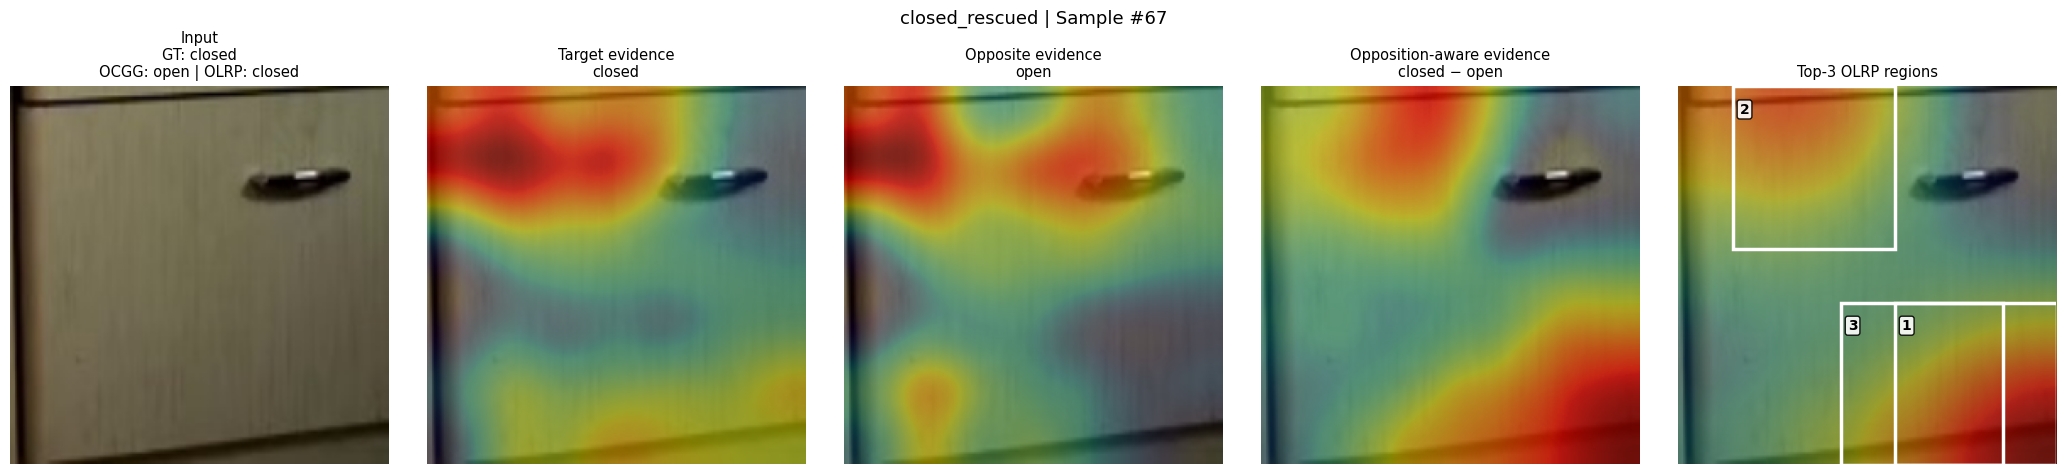

Saved: /kaggle/working/olrp_heatmaps/empty_rescued_sample_865.png


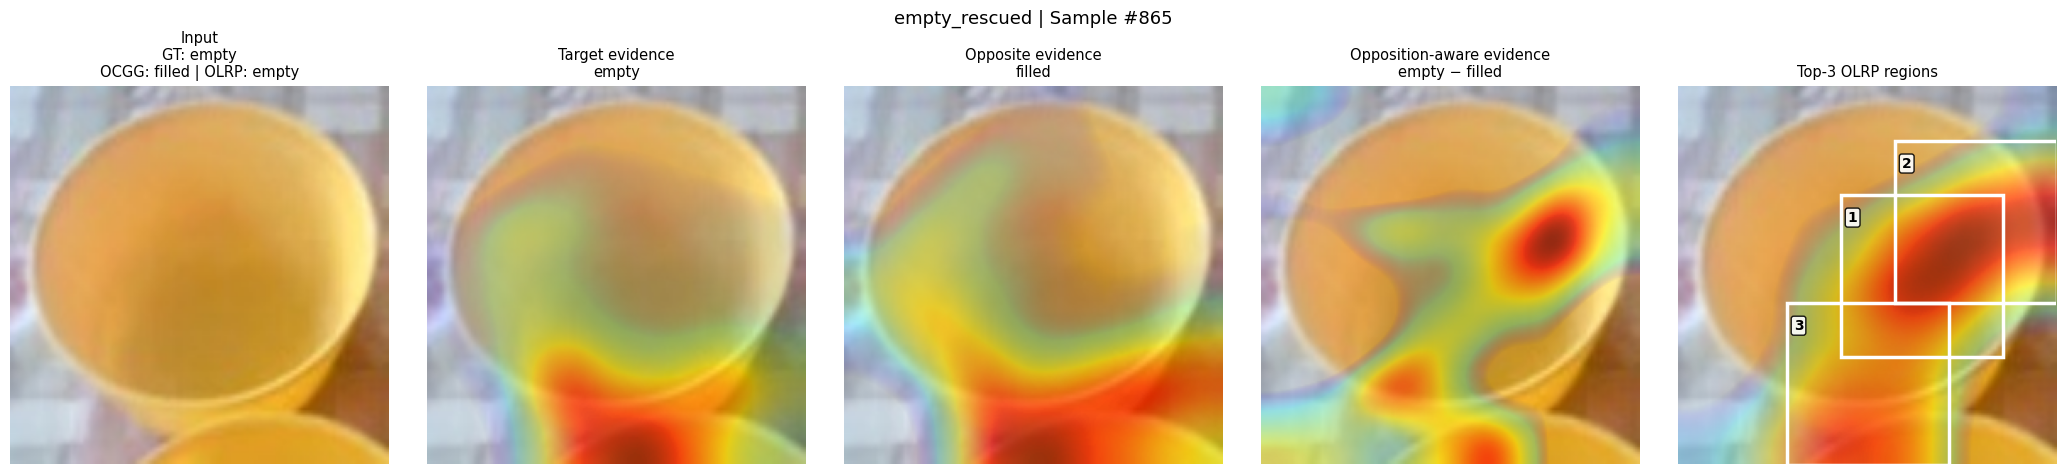

Saved: /kaggle/working/olrp_heatmaps/unfolded_rescued_sample_2327.png


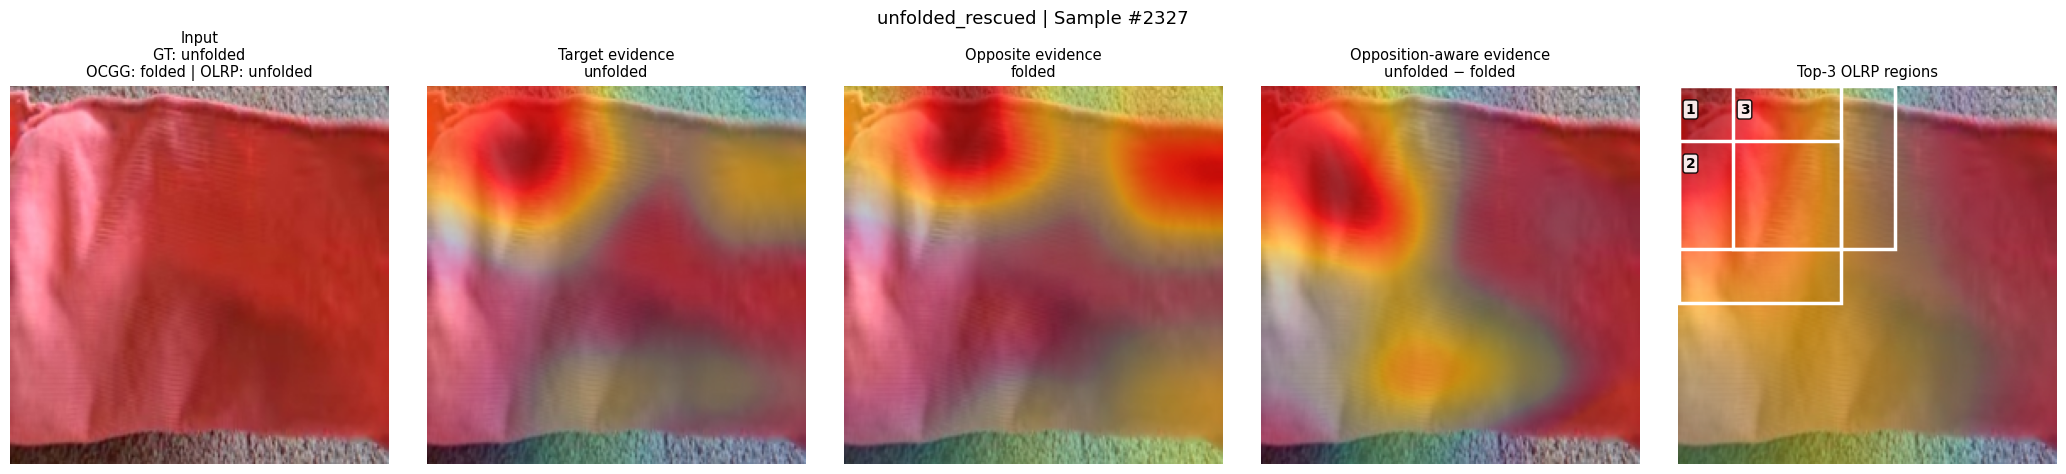

Saved: /kaggle/working/olrp_heatmaps/open_harmed_sample_1849.png


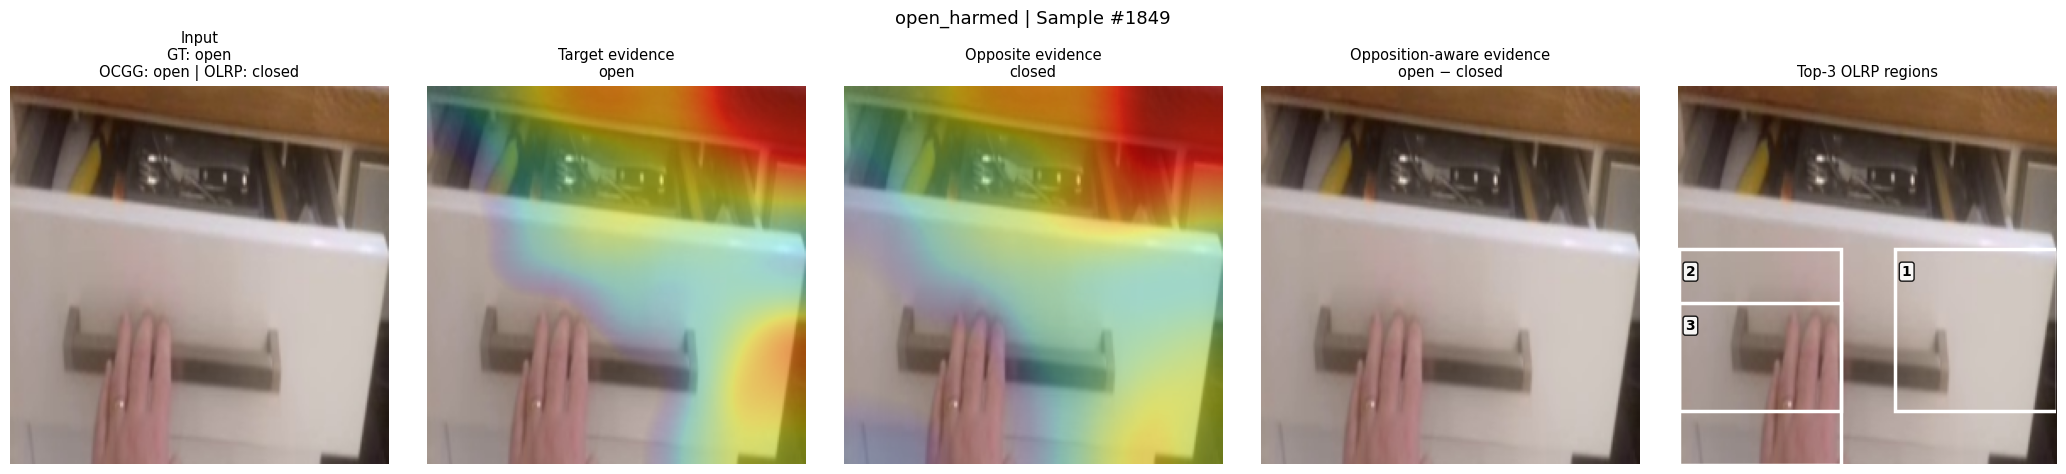

In [66]:
# ============================================================
# GENERATE FINAL HEATMAP FIGURES
# ============================================================

case_to_gt = {
    "closed_rescued": "closed",
    "empty_rescued": "empty",
    "unfolded_rescued": "unfolded",
    "open_harmed": "open",
}

for case_name, gt_state in case_to_gt.items():
    if case_name not in chosen_examples:
        print(f"Skipping {case_name} (not found)")
        continue

    idx = chosen_examples[case_name]
    image_tensor = chosen_image_tensors[idx]

    plot_olrp_case(
        case_name=case_name,
        sample_idx=idx,
        image_tensor=image_tensor,
        gt_state=gt_state,
        save=True
    )


/tmp/ipykernel_112/3021214209.py:161: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(


Saved: /kaggle/working/olrp_heatmaps/compact_olrp_panel.png


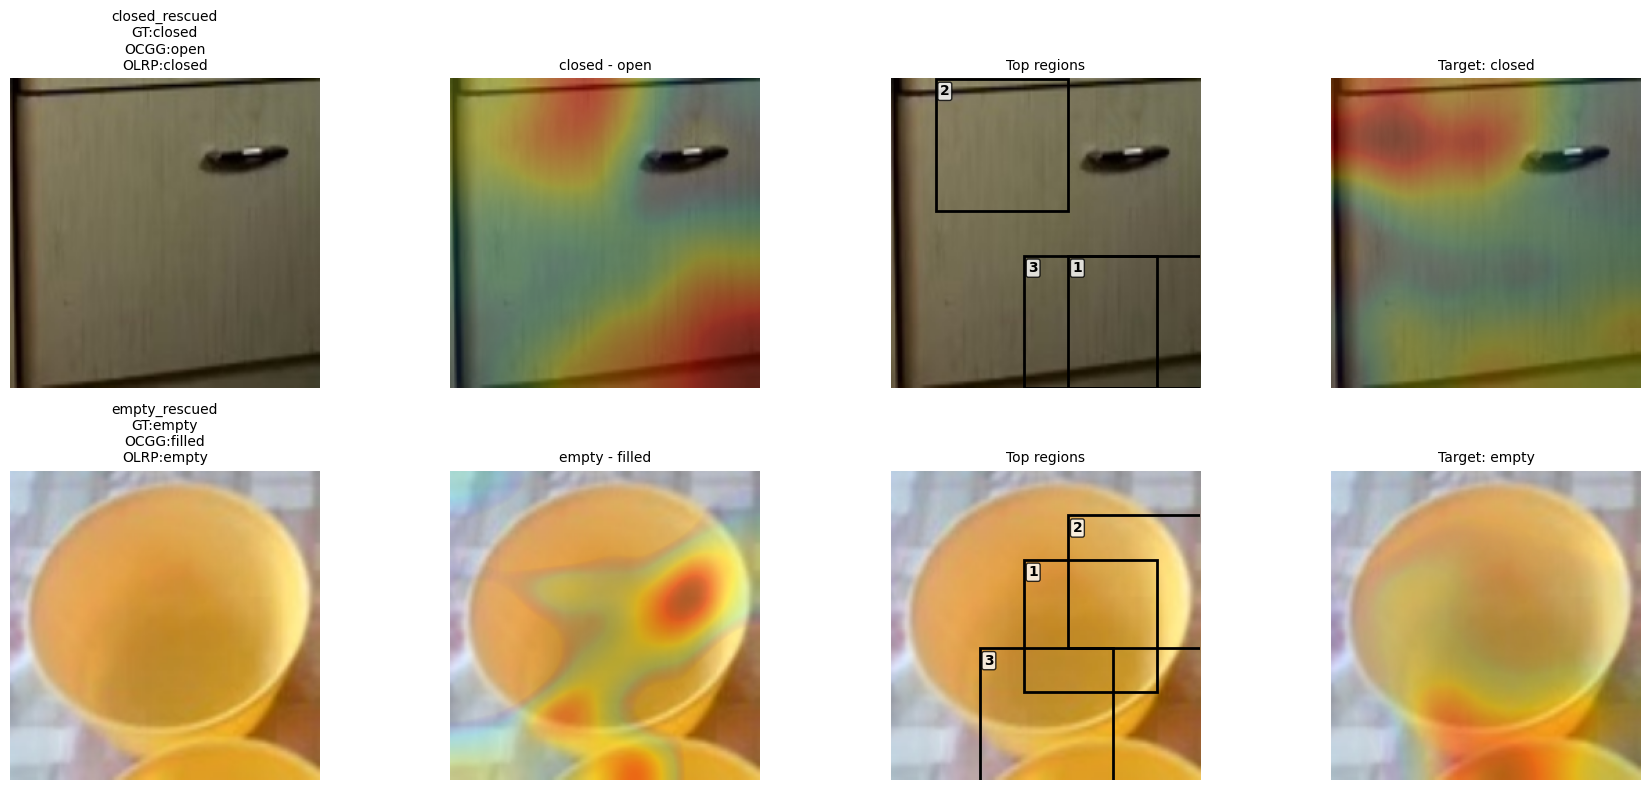

In [67]:
# ============================================================
# OPTIONAL: COMPACT 2x2 PANEL OF INPUT + CONTRASTIVE HEATMAP
# ============================================================

def plot_compact_panel(case_order):
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))

    for row, case_name in enumerate(case_order):
        if case_name not in chosen_examples:
            continue

        gt_state = case_to_gt[case_name]
        idx = chosen_examples[case_name]
        image_tensor = chosen_image_tensors[idx]

        ocgg_pred = OSDD_CLASSES[int(ocgg_final_preds[idx])]
        olrp_pred = OSDD_CLASSES[int(olrp_final_preds[idx])]
        opposite_state = OPPOSITE_STATE[gt_state]

        (
            img_np,
            target_map_np,
            opposite_map_np,
            contrast_map_np,
            heatmap_np,
            top_boxes
        ) = get_olrp_visuals(image_tensor, gt_state)

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(
            f"{case_name}\nGT:{gt_state}\nOCGG:{ocgg_pred}\nOLRP:{olrp_pred}",
            fontsize=10
        )
        axes[row, 0].axis("off")

        axes[row, 1].imshow(img_np)
        axes[row, 1].imshow(contrast_map_np, alpha=0.60, cmap="jet")
        axes[row, 1].set_title(f"{gt_state} - {opposite_state}", fontsize=10)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(img_np)
        for box in top_boxes:
            rect = Rectangle((box["x"], box["y"]), box["w"], box["h"], fill=False, linewidth=2)
            axes[row, 2].add_patch(rect)
            axes[row, 2].text(
                box["x"] + 3,
                box["y"] + 12,
                str(box["rank"]),
                fontsize=10,
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.8)
            )
        axes[row, 2].set_title("Top regions", fontsize=10)
        axes[row, 2].axis("off")

        # target evidence only
        axes[row, 3].imshow(img_np)
        axes[row, 3].imshow(target_map_np, alpha=0.55, cmap="jet")
        axes[row, 3].set_title(f"Target: {gt_state}", fontsize=10)
        axes[row, 3].axis("off")

    plt.tight_layout()
    out_path = FIG_DIR / "compact_olrp_panel.png"
    plt.savefig(out_path, dpi=220, bbox_inches="tight")
    print("Saved:", out_path)
    plt.show()


plot_compact_panel([
    "closed_rescued",
    "empty_rescued",
])


## 9. Final plots and export tables

Use the following compact tables/curves directly for presentation and paper figures.


,Method,Best HM,Max Unseen,AUC
0,Original OaSC,50.07,64.82,40.16
1,OCGG,50.58,66.41,40.96
2,OCGG + Local Pooling,51.03,66.50,41.66
3,OCGG + OLRP,51.57,66.67,41.50


Saved: /kaggle/working/oasc_seen_unseen_curves.png


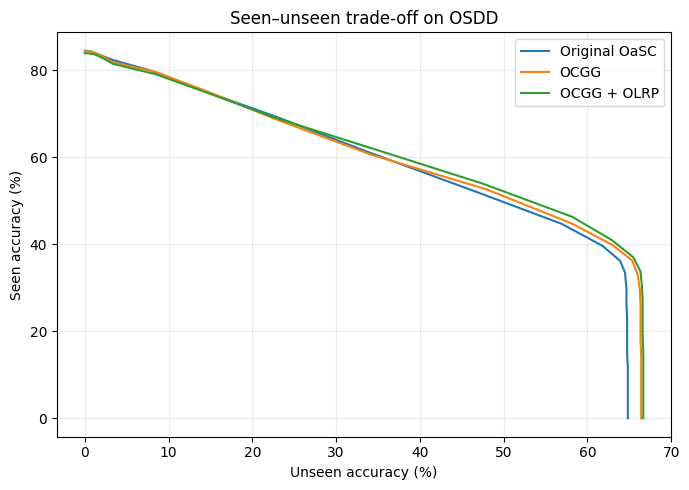

Saved paper tables to /kaggle/working/


In [68]:

# ============================================================
# Final aggregate comparison
# ============================================================

final_summary = pd.DataFrame([
    {
        "Method": "Original OaSC",
        "Best HM": 100 * best["harmonic_mean"],
        "Max Unseen": 100 * results["unseen_acc"].max(),
        "AUC": 100 * auc,
    },
    {
        "Method": "OCGG",
        "Best HM": 100 * contrastive_best["harmonic_mean"],
        "Max Unseen": 100 * contrastive_results["unseen_acc"].max(),
        "AUC": 100 * contrastive_auc,
    },
    {
        "Method": "OCGG + Local Pooling",
        "Best HM": 100 * local_only_best["harmonic_mean"],
        "Max Unseen": 100 * local_only_results["unseen_acc"].max(),
        "AUC": 100 * local_only_auc,
    },
    {
        "Method": "OCGG + OLRP",
        "Best HM": 100 * olrp_best["harmonic_mean"],
        "Max Unseen": 100 * olrp_results["unseen_acc"].max(),
        "AUC": 100 * olrp_auc,
    },
])

display(final_summary.round(2))


# Seen–unseen calibration curves
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    results["unseen_acc"] * 100,
    results["seen_acc"] * 100,
    label="Original OaSC"
)

plt.plot(
    contrastive_results["unseen_acc"] * 100,
    contrastive_results["seen_acc"] * 100,
    label="OCGG"
)

plt.plot(
    olrp_results["unseen_acc"] * 100,
    olrp_results["seen_acc"] * 100,
    label="OCGG + OLRP"
)

plt.xlabel("Unseen accuracy (%)")
plt.ylabel("Seen accuracy (%)")
plt.title("Seen–unseen trade-off on OSDD")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

curve_path = "/kaggle/working/oasc_seen_unseen_curves.png"
plt.savefig(curve_path, dpi=220, bbox_inches="tight")
print("Saved:", curve_path)
plt.show()


# Save paper-ready CSVs
final_summary.to_csv("/kaggle/working/final_results.csv", index=False)
olrp_state_analysis.to_csv("/kaggle/working/per_state_results.csv", index=False)
transition_df.to_csv("/kaggle/working/transition_analysis.csv", index=False)

print("Saved paper tables to /kaggle/working/")


## 10. What to report

### Main quantitative result
**Original OaSC → OCGG + OLRP**

- Best HM: **50.07 → 51.57** (+1.50 pp)
- Max Unseen: **64.82 → 66.67** (+1.85 pp)
- AUC: **40.16 → 41.50** (+1.34)

### Semantic mechanism
OCGG suppresses contradictory semantic neighbors, e.g. `closed` under `open` moves from rank 1 to rank 189.

### Visual mechanism
Local region pooling supplies the main visual gain; opposition-aware subtraction further improves the **best harmonic mean** and **maximum unseen accuracy**, although local-only pooling has a slightly higher AUC (41.66 vs 41.50).

### Limitation
OLRP is asymmetric across state pairs. It strongly helps `closed`, `unfolded`, and `empty`, but can overcorrect states such as `open`, `folded`, and `plugged`. Report this rather than claiming universal per-class improvement.


In [69]:
# ============================================================
# MIT-STATES — CHECK RELEASED FILES
# ============================================================

from pathlib import Path

MIT_ROOT = METHOD_DIR / "datasets/mit_states"
MIT_TEST_DIR = MIT_ROOT / "test"
MIT_TRAIN_DIR = MIT_ROOT / "train"
MIT_VAL_DIR = MIT_ROOT / "val"

MIT_EMB_PATH = METHOD_DIR / "embeddings/mit_emb.pred"
MIT_CKPT_DIR = METHOD_DIR / "saved_checkpoints/mit"

print("MIT root      :", MIT_ROOT, MIT_ROOT.exists())
print("MIT train     :", MIT_TRAIN_DIR, MIT_TRAIN_DIR.exists())
print("MIT val       :", MIT_VAL_DIR, MIT_VAL_DIR.exists())
print("MIT test      :", MIT_TEST_DIR, MIT_TEST_DIR.exists())
print("MIT embeddings:", MIT_EMB_PATH, MIT_EMB_PATH.exists())
print("MIT ckpt dir  :", MIT_CKPT_DIR, MIT_CKPT_DIR.exists())

print("\n===== CHECKPOINT FILES =====")

mit_checkpoint_candidates = [
    p for p in MIT_CKPT_DIR.rglob("*")
    if p.is_file()
]

for p in mit_checkpoint_candidates:
    print(p)

MIT root      : /kaggle/working/OaSC_official/OaSC/datasets/mit_states True
MIT train     : /kaggle/working/OaSC_official/OaSC/datasets/mit_states/train True
MIT val       : /kaggle/working/OaSC_official/OaSC/datasets/mit_states/val True
MIT test      : /kaggle/working/OaSC_official/OaSC/datasets/mit_states/test True
MIT embeddings: /kaggle/working/OaSC_official/OaSC/embeddings/mit_emb.pred True
MIT ckpt dir  : /kaggle/working/OaSC_official/OaSC/saved_checkpoints/mit True

===== CHECKPOINT FILES =====
/kaggle/working/OaSC_official/OaSC/saved_checkpoints/mit/finetuned_weights.pth


In [70]:
# ============================================================
# LOAD MIT OaSC STATE CLASSIFIERS
# ============================================================

import torch

GRAPH_TYPE = "conceptnet_wordnet_hop1_thresh_10"

def torch_load_compat(path, map_location="cpu"):
    try:
        return torch.load(
            path,
            map_location=map_location,
            weights_only=False
        )
    except TypeError:
        return torch.load(
            path,
            map_location=map_location
        )


MIT_CLASSES = [
    "closed",
    "empty",
    "filled",
    "folded",
    "open"
]

MIT_CLASS_TO_ID = {
    name: i
    for i, name in enumerate(MIT_CLASSES)
}


mit_emb_file = torch_load_compat(
    MIT_EMB_PATH
)

print("Embedding keys:")
print(mit_emb_file.keys())

raw_mit_vectors = (
    mit_emb_file[GRAPH_TYPE]
    .float()
)

print(
    "Raw released tensor:",
    raw_mit_vectors.shape
)


# Authors' test.py behavior
if len(raw_mit_vectors) > 5:

    MIT_FULL_VECTOR_INDICES = [
        0, 2, 3, 4, 5
    ]

    mit_state_vectors = (
        raw_mit_vectors[
            MIT_FULL_VECTOR_INDICES
        ]
    )

else:

    mit_state_vectors = (
        raw_mit_vectors
    )


print(
    "MIT classifier tensor:",
    mit_state_vectors.shape
)

assert mit_state_vectors.shape == (
    5,
    2049
)

for i, state in enumerate(MIT_CLASSES):
    print(
        i,
        state
    )

Embedding keys:
dict_keys(['osdd2', 'osdd_ir_9_graph', 'osdd_wordnet_states', 'conceptnet_hop2_thresh_10', 'wordnet_states_hop2', 'conceptnet_hop1_thresh_10', 'conceptnet_hop1_thresh_0', 'conceptnet_wordnet_hop2_thresh_10', 'conceptnet_wordnet_hop1_thresh_0', 'conceptnet_wordnet_hop1_thresh_10', 'visualgenome_states_hops0', 'visualgenome_states_hops1', 'visualgenome_hops1'])
Raw released tensor: torch.Size([9, 2049])
MIT classifier tensor: torch.Size([5, 2049])
0 closed
1 empty
2 filled
3 folded
4 open


In [71]:
# ============================================================
# LOAD RELEASED MIT RESNET-101
# ============================================================

import torch.nn as nn
from torchvision.models import resnet101


preferred_ckpt = (
    MIT_CKPT_DIR
    / "finetuned_weights.pth"
)


if preferred_ckpt.exists():

    MIT_CKPT_PATH = preferred_ckpt

else:

    valid_candidates = [
        p
        for p in mit_checkpoint_candidates
        if p.suffix.lower()
        in {".pth", ".pt", ".ckpt"}
    ]

    if len(valid_candidates) != 1:

        print(
            "Please inspect these checkpoint candidates:"
        )

        for p in valid_candidates:
            print(p)

        raise RuntimeError(
            "Could not automatically choose MIT checkpoint."
        )

    MIT_CKPT_PATH = valid_candidates[0]


print(
    "Using checkpoint:",
    MIT_CKPT_PATH
)


try:

    cnn = resnet101(
        weights=None
    )

except TypeError:

    cnn = resnet101(
        pretrained=False
    )


cnn.fc = nn.Identity()


ckpt = torch_load_compat(
    MIT_CKPT_PATH
)


if (
    isinstance(ckpt, dict)
    and "state_dict" in ckpt
):

    ckpt = ckpt[
        "state_dict"
    ]


ckpt = {
    k.replace(
        "module.",
        ""
    ): v

    for k, v in ckpt.items()
}


ckpt.pop(
    "fc.weight",
    None
)

ckpt.pop(
    "fc.bias",
    None
)


missing, unexpected = (
    cnn.load_state_dict(
        ckpt,
        strict=False
    )
)


print(
    "Missing:",
    missing
)

print(
    "Unexpected:",
    unexpected
)


cnn = (
    cnn
    .to(DEVICE)
    .eval()
)

mit_state_vectors = (
    mit_state_vectors
    .to(DEVICE)
)


Using checkpoint: /kaggle/working/OaSC_official/OaSC/saved_checkpoints/mit/finetuned_weights.pth
Missing: []
Unexpected: []


In [72]:
# ============================================================
# MIT-STATES DATASET + OFFICIAL GZSL SPLIT
# ============================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


MIT_UNSEEN_NAMES = [
    "closed",
    "folded",
    "filled"
]


UNSEEN_IDS = [
    MIT_CLASS_TO_ID[x]
    for x in MIT_UNSEEN_NAMES
]


SEEN_IDS = [
    i
    for i in range(
        len(MIT_CLASSES)
    )
    if i not in UNSEEN_IDS
]


transform = transforms.Compose([
    transforms.Resize(
        [224, 224]
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])


test_ds = datasets.ImageFolder(
    MIT_TEST_DIR,
    transform=transform
)


print(
    "ImageFolder classes:",
    test_ds.classes
)

print(
    "Test images:",
    len(test_ds)
)


folder_idx_to_global = {
    folder_idx:
        MIT_CLASS_TO_ID[state]

    for state, folder_idx
    in test_ds.class_to_idx.items()
}


print(
    "Seen:",
    [
        MIT_CLASSES[i]
        for i in SEEN_IDS
    ]
)

print(
    "Unseen:",
    [
        MIT_CLASSES[i]
        for i in UNSEEN_IDS
    ]
)

print(
    "Folder mapping:",
    folder_idx_to_global
)


test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

ImageFolder classes: ['closed', 'empty', 'filled', 'folded', 'open']
Test images: 354
Seen: ['empty', 'open']
Unseen: ['closed', 'folded', 'filled']
Folder mapping: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [73]:
# ============================================================
# CACHE MIT TEST FEATURES
# ============================================================

import numpy as np
import pandas as pd
from tqdm.auto import tqdm


feature_batches = []
target_batches = []


cnn.eval()


with torch.inference_mode():

    for images, folder_labels in tqdm(
        test_loader,
        desc="Caching MIT-States features"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        visual = cnn(
            images
        )


        visual_aug = torch.cat(
            [
                visual,

                torch.ones(
                    visual.shape[0],
                    1,
                    device=DEVICE
                )
            ],
            dim=1
        )


        targets = torch.tensor(
            [
                folder_idx_to_global[
                    int(x)
                ]
                for x in folder_labels
            ],
            dtype=torch.long
        )


        feature_batches.append(
            visual_aug.cpu()
        )

        target_batches.append(
            targets
        )


cached_test_features_aug = (
    torch.cat(
        feature_batches
    )
)

cached_test_targets = (
    torch.cat(
        target_batches
    )
)


print(
    cached_test_features_aug.shape
)

print(
    cached_test_targets.shape
)

Caching MIT-States features:   0%|          | 0/3 [00:00<?, ?it/s]

torch.Size([354, 2049])
torch.Size([354])


In [74]:
# ============================================================
# MIT GZSL EVALUATION
# ============================================================

gammas = np.arange(
    -5.0,
    15.125,
    0.5
)


def evaluate_gamma(
    scores,
    targets,
    gamma
):

    calibrated = (
        scores.clone()
    )

    calibrated[
        :,
        UNSEEN_IDS
    ] += float(gamma)


    pred = calibrated.argmax(
        dim=1
    )


    seen_mask = torch.tensor(
        [
            int(y) in SEEN_IDS
            for y in targets
        ],
        dtype=torch.bool
    )


    unseen_mask = (
        ~seen_mask
    )


    seen_acc = (
        (
            pred[seen_mask]
            ==
            targets[seen_mask]
        )
        .float()
        .mean()
        .item()
    )


    unseen_acc = (
        (
            pred[unseen_mask]
            ==
            targets[unseen_mask]
        )
        .float()
        .mean()
        .item()
    )


    hm = (
        0.0
        if seen_acc + unseen_acc == 0
        else
        2
        * seen_acc
        * unseen_acc
        /
        (
            seen_acc
            + unseen_acc
        )
    )


    total = (
        (pred == targets)
        .float()
        .mean()
        .item()
    )


    return (
        total,
        seen_acc,
        unseen_acc,
        hm
    )


def evaluate_score_matrix(
    score_matrix,
    targets,
    method
):

    rows = []


    for gamma in gammas:

        total, seen, unseen, hm = (
            evaluate_gamma(
                score_matrix,
                targets,
                gamma
            )
        )


        rows.append({
            "gamma": gamma,
            "total_acc": total,
            "seen_acc": seen,
            "unseen_acc": unseen,
            "harmonic_mean": hm
        })


    df = pd.DataFrame(
        rows
    )


    best = df.loc[
        df[
            "harmonic_mean"
        ].idxmax()
    ]


    try:

        auc = np.trapezoid(
            df["seen_acc"],
            df["unseen_acc"]
        )

    except AttributeError:

        auc = np.trapz(
            df["seen_acc"],
            df["unseen_acc"]
        )


    print(
        "\n=============================================="
    )

    print(method)

    print(
        "=============================================="
    )

    print(
        f"Best gamma       : "
        f"{best['gamma']:.2f}"
    )

    print(
        f"Seen @ best HM   : "
        f"{100*best['seen_acc']:.2f}%"
    )

    print(
        f"Unseen @ best HM : "
        f"{100*best['unseen_acc']:.2f}%"
    )

    print(
        f"Best HM          : "
        f"{100*best['harmonic_mean']:.2f}%"
    )

    print(
        f"Max seen acc     : "
        f"{100*df['seen_acc'].max():.2f}%"
    )

    print(
        f"Max unseen acc   : "
        f"{100*df['unseen_acc'].max():.2f}%"
    )

    print(
        f"AUC              : "
        f"{100*auc:.2f}"
    )


    return df, best, auc

In [75]:
# ============================================================
# RELEASED MIT OaSC BASELINE
# ============================================================

baseline_scores = (
    cached_test_features_aug.float()
    @
    mit_state_vectors.detach().cpu().float().T
)


mit_results, mit_best, mit_auc = (
    evaluate_score_matrix(
        baseline_scores,
        cached_test_targets,
        "ORIGINAL OaSC — MIT-STATES"
    )
)


ORIGINAL OaSC — MIT-STATES
Best gamma       : 0.00
Seen @ best HM   : 47.62%
Unseen @ best HM : 55.77%
Best HM          : 51.37%
Max seen acc     : 85.71%
Max unseen acc   : 69.87%
AUC              : 40.99


In [76]:
required = [
    "g",
    "rw_adj_lists",
    "state_node_ids",
    "state_clip_features",
    "clip_node_features",
    "trgcn_predict_nodes",
]

for name in required:
    assert name in globals(), f"Missing: {name}"

print("✓ KG + CLIP + Tr-GCN setup ready")

✓ KG + CLIP + Tr-GCN setup ready


In [77]:
# ============================================================
# MIT — SAME AMBIGUITY-ADAPTIVE WEIGHTS AS OSDD
# ============================================================

import copy
import math
import torch
import pandas as pd


REFERENCE_STATES = [
    "closed",
    "containing",
    "empty",
    "filled",
    "folded",
    "open",
    "plugged",
    "unfolded",
    "unplugged",
]


def deduplicate_neighbors(items):

    best = {}

    for item in items:

        nid = int(item[0])
        rw = float(item[-1])

        if nid not in best or rw > float(best[nid][-1]):
            best[nid] = item

    return list(best.values())


def minmax01(values):

    x = torch.tensor(
        values,
        dtype=torch.float32
    )

    if len(x) == 0:
        return x

    if x.max() > x.min():

        return (
            x - x.min()
        ) / (
            x.max() - x.min()
        )

    return torch.ones_like(x)


# ------------------------------------------------------------
# Same ambiguity definition used on OSDD
# ------------------------------------------------------------

neighbor_counts = {}

for state in REFERENCE_STATES:

    sid = state_node_ids[state]

    unique_items = deduplicate_neighbors(
        rw_adj_lists[sid]
    )

    neighbor_counts[state] = len(unique_items)


N_MAX = max(
    neighbor_counts.values()
)


state_ambiguity = {}
state_clip_weights = {}


LAMBDA_MIN = 0.40
LAMBDA_MAX = 0.90


for state in REFERENCE_STATES:

    sid = state_node_ids[state]

    items = deduplicate_neighbors(
        rw_adj_lists[sid]
    )

    n = len(items)


    if n <= 1:

        ambiguity = 0.0

    else:

        rw = torch.tensor(
            [
                max(
                    float(item[-1]),
                    0.0
                )
                for item in items
            ],
            dtype=torch.float32
        )


        if rw.sum() <= 0:

            entropy_norm = 0.0

        else:

            p = (
                rw
                /
                rw.sum()
            )

            entropy = -(
                p
                *
                torch.log(
                    p + 1e-12
                )
            ).sum().item()


            entropy_norm = (
                entropy
                /
                math.log(n)
            )


        size_factor = (
            math.log1p(n)
            /
            math.log1p(N_MAX)
        )


        ambiguity = (
            entropy_norm
            *
            size_factor
        )


    state_ambiguity[state] = ambiguity


    state_clip_weights[state] = (
        LAMBDA_MIN
        +
        ambiguity
        *
        (
            LAMBDA_MAX
            -
            LAMBDA_MIN
        )
    )


display(
    pd.DataFrame([
        {
            "State": s,
            "Neighbors": neighbor_counts[s],
            "Ambiguity": state_ambiguity[s],
            "Semantic weight": state_clip_weights[s],
        }
        for s in REFERENCE_STATES
    ]).round(3)
)

,State,Neighbors,Ambiguity,Semantic weight
0,closed,72,0.744,0.772
1,containing,28,0.622,0.711
2,empty,82,0.807,0.803
3,filled,21,0.574,0.687
4,folded,23,0.588,0.694
5,open,192,0.945,0.872
6,plugged,2,0.207,0.504
7,unfolded,1,0.000,0.400
8,unplugged,2,0.208,0.504


In [78]:
# ============================================================
# MIT — BUILD FIXED / ADAPTIVE / OCGG GRAPHS
# ============================================================

MIT_GRAPH_STATES = [
    "closed",
    "empty",
    "filled",
    "folded",
    "open",

    # auxiliary only; required as folded's opposite
    "unfolded",
]


OPPOSITE_STATE = {

    "open": "closed",
    "closed": "open",

    "empty": "filled",
    "filled": "empty",

    "folded": "unfolded",
    "unfolded": "folded",
}


def build_mit_semantic_graph(mode):

    """
    mode:
        fixed
        adaptive
        ocgg
    """

    modified_rw = copy.deepcopy(
        rw_adj_lists
    )


    for state in MIT_GRAPH_STATES:

        sid = state_node_ids[state]


        items = deduplicate_neighbors(
            rw_adj_lists[sid]
        )


        if len(items) == 0:
            continue


        # ====================================================
        # KG structural score
        # ====================================================

        rw_raw = [
            float(item[-1])
            for item in items
        ]

        rw_norm = minmax01(
            rw_raw
        )


        # ====================================================
        # CLIP semantic score
        # ====================================================

        target_feature = (
            state_clip_features[state]
            .cpu()
        )


        semantic_raw = []


        for item in items:

            nid = int(
                item[0]
            )

            neighbor_feature = (
                clip_node_features[nid]
                .cpu()
            )


            target_sim = torch.dot(
                target_feature,
                neighbor_feature
            ).item()


            # -----------------------------------------------
            # OCGG:
            # target similarity - opposite similarity
            # -----------------------------------------------

            if mode == "ocgg":

                opposite = (
                    OPPOSITE_STATE[state]
                )

                opposite_feature = (
                    state_clip_features[
                        opposite
                    ]
                    .cpu()
                )


                opposite_sim = torch.dot(
                    opposite_feature,
                    neighbor_feature
                ).item()


                semantic_raw.append(
                    target_sim
                    -
                    opposite_sim
                )


            # -----------------------------------------------
            # Fixed / adaptive:
            # absolute state similarity
            # -----------------------------------------------

            else:

                semantic_raw.append(
                    target_sim
                )


        semantic_norm = minmax01(
            semantic_raw
        )


        # ====================================================
        # Fusion weight
        # ====================================================

        if mode == "fixed":

            semantic_weight = 0.80

        else:

            semantic_weight = float(
                state_clip_weights[state]
            )


        kg_weight = (
            1.0
            -
            semantic_weight
        )


        combined = (
            kg_weight
            *
            rw_norm

            +

            semantic_weight
            *
            semantic_norm
        )


        # ====================================================
        # Replace ranking score
        # ====================================================

        reranked = []


        for item, score in zip(
            items,
            combined
        ):

            item_new = list(
                item
            )

            item_new[-1] = float(
                score
            )

            reranked.append(
                tuple(item_new)
            )


        reranked.sort(
            key=lambda x: x[-1],
            reverse=True
        )


        # IMPORTANT:
        # no pre-truncation
        modified_rw[
            sid
        ] = reranked


    graph = copy.deepcopy(g)

    graph[
        "rw_adj_lists"
    ] = modified_rw


    return graph


mit_fixed_graph = (
    build_mit_semantic_graph(
        "fixed"
    )
)

mit_adaptive_graph = (
    build_mit_semantic_graph(
        "adaptive"
    )
)

mit_ocgg_graph = (
    build_mit_semantic_graph(
        "ocgg"
    )
)


print("✓ MIT semantic graphs built")

✓ MIT semantic graphs built


In [79]:
# ============================================================
# MIT — GENERATE Tr-GCN CLASSIFIERS
# ============================================================

MIT_STATE_NODE_IDS = [
    state_node_ids[state]
    for state in MIT_CLASSES
]


with torch.inference_mode():

    mit_fixed_vectors = (
        trgcn_predict_nodes(
            MIT_STATE_NODE_IDS,
            mit_fixed_graph
        )
    )


    mit_adaptive_vectors = (
        trgcn_predict_nodes(
            MIT_STATE_NODE_IDS,
            mit_adaptive_graph
        )
    )


    mit_ocgg_vectors = (
        trgcn_predict_nodes(
            MIT_STATE_NODE_IDS,
            mit_ocgg_graph
        )
    )


    # Auxiliary only:
    # needed by OLRP for folded vs unfolded
    mit_unfolded_aux_vector = (
        trgcn_predict_nodes(
            [
                state_node_ids[
                    "unfolded"
                ]
            ],
            mit_ocgg_graph
        )[0]
    )


print(
    "Fixed:",
    mit_fixed_vectors.shape
)

print(
    "Adaptive:",
    mit_adaptive_vectors.shape
)

print(
    "OCGG:",
    mit_ocgg_vectors.shape
)

print(
    "Aux unfolded:",
    mit_unfolded_aux_vector.shape
)

Fixed: torch.Size([5, 2049])
Adaptive: torch.Size([5, 2049])
OCGG: torch.Size([5, 2049])
Aux unfolded: torch.Size([2049])


In [80]:
# ============================================================
# MIT — LAYER4 SPATIAL FEATURE HOOK
# ============================================================

import torch.nn.functional as F


if "mit_olrp_hook_handle" in globals():

    try:
        mit_olrp_hook_handle.remove()

    except Exception:
        pass


mit_olrp_cache = {}


def mit_olrp_hook(
    module,
    inp,
    out
):

    mit_olrp_cache[
        "spatial"
    ] = out


backbone = (
    cnn.module
    if hasattr(cnn, "module")
    else cnn
)


mit_olrp_hook_handle = (
    backbone.layer4
    .register_forward_hook(
        mit_olrp_hook
    )
)


# quick validation

images, _ = next(
    iter(test_loader)
)

images = images.to(
    DEVICE
)


with torch.inference_mode():

    pooled = cnn(
        images
    )

    spatial = (
        mit_olrp_cache[
            "spatial"
        ]
    )


spatial_mean = (
    spatial.mean(
        dim=(-2, -1)
    )
)


print(
    "Spatial:",
    spatial.shape
)

print(
    "Mean cosine:",
    F.cosine_similarity(
        pooled,
        spatial_mean,
        dim=1
    ).mean().item()
)

Spatial: torch.Size([128, 2048, 7, 7])
Mean cosine: 1.0


In [81]:
# ============================================================
# MIT — LOCAL REGION POOLING + OLRP
# ============================================================

REGION_SIZE = 3
TOP_REGIONS = 3
LOCAL_ALPHA = 0.10


# ------------------------------------------------------------
# Final OCGG output classifier
# ------------------------------------------------------------

mit_ocgg_device = (
    mit_ocgg_vectors
    .detach()
    .to(DEVICE)
)


mit_ocgg_w = (
    mit_ocgg_device[
        :,
        :-1
    ]
)

mit_ocgg_b = (
    mit_ocgg_device[
        :,
        -1
    ]
)


# ------------------------------------------------------------
# Auxiliary unfolded classifier
# ------------------------------------------------------------

unfolded_aux = (
    mit_unfolded_aux_vector
    .detach()
    .to(DEVICE)
)

unfolded_w = (
    unfolded_aux[:-1]
)


# ------------------------------------------------------------
# Local state order
#
# indices 0-4 = actual prediction classes
# index 5     = auxiliary unfolded
# ------------------------------------------------------------

MIT_LOCAL_STATES = [
    "closed",
    "empty",
    "filled",
    "folded",
    "open",
    "unfolded"
]


all_local_w = torch.cat(
    [
        mit_ocgg_w,

        unfolded_w
        .unsqueeze(0)
    ],
    dim=0
)


LOCAL_STATE_TO_ID = {
    state: i
    for i, state
    in enumerate(
        MIT_LOCAL_STATES
    )
}


MIT_VISUAL_OPPOSITES = {

    "closed": "open",

    "empty": "filled",

    "filled": "empty",

    "folded": "unfolded",

    "open": "closed",
}


local_only_batches = []
olrp_batches = []
target_batches = []


cnn.eval()


with torch.inference_mode():

    for images, labels in tqdm(
        test_loader,
        desc="MIT local visual inference"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        # ====================================================
        # GLOBAL OCGG
        # ====================================================

        pooled = cnn(
            images
        )

        spatial = (
            mit_olrp_cache[
                "spatial"
            ]
        )


        global_scores = (
            pooled
            @ mit_ocgg_w.T

            +

            mit_ocgg_b.unsqueeze(
                0
            )
        )


        # ====================================================
        # SPATIAL SCORES
        #
        # includes auxiliary unfolded
        # ====================================================

        patch_scores = torch.einsum(
            "bchw,sc->bshw",
            spatial,
            all_local_w
        )


        B, S, H, W = (
            patch_scores.shape
        )


        # ====================================================
        # 3×3 coherent regions
        # ====================================================

        region_scores = F.avg_pool2d(

            patch_scores.reshape(
                B * S,
                1,
                H,
                W
            ),

            kernel_size=REGION_SIZE,

            stride=1
        )


        Hr, Wr = (
            region_scores.shape[
                -2:
            ]
        )


        region_scores = (
            region_scores.reshape(
                B,
                S,
                Hr * Wr
            )
        )


        k = min(
            TOP_REGIONS,
            Hr * Wr
        )


        local_score = torch.topk(
            region_scores,
            k=k,
            dim=-1
        ).values.mean(
            dim=-1
        )


        global_visual = (
            patch_scores.mean(
                dim=(-2, -1)
            )
        )


        gain = (
            local_score
            -
            global_visual
        )


        # ====================================================
        # LOCAL-ONLY ABLATION
        # ====================================================

        local_only_correction = (
            gain[
                :,
                :5
            ]
        )


        local_only_final = (
            global_scores

            +

            LOCAL_ALPHA
            *
            local_only_correction
        )


        # ====================================================
        # OLRP
        # ====================================================

        olrp_correction = (
            torch.zeros_like(
                global_scores
            )
        )


        for state in MIT_CLASSES:

            target_idx = (
                MIT_CLASS_TO_ID[
                    state
                ]
            )


            opposite = (
                MIT_VISUAL_OPPOSITES[
                    state
                ]
            )


            target_local_idx = (
                LOCAL_STATE_TO_ID[
                    state
                ]
            )


            opposite_local_idx = (
                LOCAL_STATE_TO_ID[
                    opposite
                ]
            )


            olrp_correction[
                :,
                target_idx
            ] = (

                gain[
                    :,
                    target_local_idx
                ]

                -

                gain[
                    :,
                    opposite_local_idx
                ]

            )


        olrp_final = (
            global_scores

            +

            LOCAL_ALPHA
            *
            olrp_correction
        )


        batch_targets = torch.tensor(
            [
                folder_idx_to_global[
                    int(x)
                ]
                for x in labels
            ],
            dtype=torch.long
        )


        local_only_batches.append(
            local_only_final.cpu()
        )

        olrp_batches.append(
            olrp_final.cpu()
        )

        target_batches.append(
            batch_targets
        )


mit_local_scores = torch.cat(
    local_only_batches
)

mit_olrp_scores = torch.cat(
    olrp_batches
)

mit_targets = torch.cat(
    target_batches
)


assert torch.equal(
    mit_targets,
    cached_test_targets
)


print(
    "Local:",
    mit_local_scores.shape
)

print(
    "OLRP :",
    mit_olrp_scores.shape
)

MIT local visual inference:   0%|          | 0/3 [00:00<?, ?it/s]

Local: torch.Size([354, 5])
OLRP : torch.Size([354, 5])


In [82]:
# ============================================================
# MIT — VISUAL EVALUATION
# ============================================================

mit_local_results, mit_local_best, mit_local_auc = (
    evaluate_score_matrix(
        mit_local_scores,
        mit_targets,
        "OCGG + LOCAL POOLING — MIT"
    )
)


mit_olrp_results, mit_olrp_best, mit_olrp_auc = (
    evaluate_score_matrix(
        mit_olrp_scores,
        mit_targets,
        "OCGG + OLRP — MIT"
    )
)


OCGG + LOCAL POOLING — MIT
Best gamma       : -0.50
Seen @ best HM   : 57.14%
Unseen @ best HM : 53.21%
Best HM          : 55.10%
Max seen acc     : 85.71%
Max unseen acc   : 75.32%
AUC              : 44.78

OCGG + OLRP — MIT
Best gamma       : -0.50
Seen @ best HM   : 54.76%
Unseen @ best HM : 53.21%
Best HM          : 53.97%
Max seen acc     : 83.33%
Max unseen acc   : 75.64%
AUC              : 43.03


In [83]:
# ============================================================
# MIT — EVALUATE ALL GRAPH VARIANTS
# Run this BEFORE the final table
# ============================================================

required_vectors = [
    "mit_fixed_vectors",
    "mit_adaptive_vectors",
    "mit_ocgg_vectors",
]

for name in required_vectors:
    assert name in globals(), (
        f"{name} is missing. "
        "Run the graph-building + Tr-GCN generation cells first."
    )


def scores_from_vectors_mit(vectors):
    return (
        cached_test_features_aug.float()
        @
        vectors.detach().cpu().float().T
    )


# ------------------------------------------------------------
# Fixed CLIP KG
# ------------------------------------------------------------

mit_fixed_scores = scores_from_vectors_mit(
    mit_fixed_vectors
)

mit_fixed_results, mit_fixed_best, mit_fixed_auc = (
    evaluate_score_matrix(
        mit_fixed_scores,
        cached_test_targets,
        "FIXED CLIP KG — MIT"
    )
)


# ------------------------------------------------------------
# Adaptive CLIP KG
# ------------------------------------------------------------

mit_adaptive_scores = scores_from_vectors_mit(
    mit_adaptive_vectors
)

mit_adaptive_results, mit_adaptive_best, mit_adaptive_auc = (
    evaluate_score_matrix(
        mit_adaptive_scores,
        cached_test_targets,
        "ADAPTIVE CLIP KG — MIT"
    )
)


# ------------------------------------------------------------
# OCGG
# ------------------------------------------------------------

mit_ocgg_scores = scores_from_vectors_mit(
    mit_ocgg_vectors
)

mit_ocgg_results, mit_ocgg_best, mit_ocgg_auc = (
    evaluate_score_matrix(
        mit_ocgg_scores,
        cached_test_targets,
        "OCGG — MIT"
    )
)


print("\n✓ All MIT graph variants evaluated")


FIXED CLIP KG — MIT
Best gamma       : -0.50
Seen @ best HM   : 57.14%
Unseen @ best HM : 52.24%
Best HM          : 54.58%
Max seen acc     : 85.71%
Max unseen acc   : 75.00%
AUC              : 45.57

ADAPTIVE CLIP KG — MIT
Best gamma       : -0.50
Seen @ best HM   : 57.14%
Unseen @ best HM : 51.92%
Best HM          : 54.41%
Max seen acc     : 85.71%
Max unseen acc   : 75.00%
AUC              : 45.50

OCGG — MIT
Best gamma       : -1.00
Seen @ best HM   : 66.67%
Unseen @ best HM : 44.87%
Best HM          : 53.64%
Max seen acc     : 83.33%
Max unseen acc   : 75.00%
AUC              : 43.47

✓ All MIT graph variants evaluated


In [84]:
# ============================================================
# MIT — FINAL ABLATION TABLE
# ============================================================

mit_final_table = pd.DataFrame([

    {
        "Method":
            "Original OaSC",

        "Best HM":
            100
            *
            mit_best[
                "harmonic_mean"
            ],

        "Max Unseen":
            100
            *
            mit_results[
                "unseen_acc"
            ].max(),

        "AUC":
            100
            *
            mit_auc
    },


    {
        "Method":
            "Fixed CLIP KG",

        "Best HM":
            100
            *
            mit_fixed_best[
                "harmonic_mean"
            ],

        "Max Unseen":
            100
            *
            mit_fixed_results[
                "unseen_acc"
            ].max(),

        "AUC":
            100
            *
            mit_fixed_auc
    },


    {
        "Method":
            "Adaptive CLIP KG",

        "Best HM":
            100
            *
            mit_adaptive_best[
                "harmonic_mean"
            ],

        "Max Unseen":
            100
            *
            mit_adaptive_results[
                "unseen_acc"
            ].max(),

        "AUC":
            100
            *
            mit_adaptive_auc
    },


    {
        "Method":
            "OCGG",

        "Best HM":
            100
            *
            mit_ocgg_best[
                "harmonic_mean"
            ],

        "Max Unseen":
            100
            *
            mit_ocgg_results[
                "unseen_acc"
            ].max(),

        "AUC":
            100
            *
            mit_ocgg_auc
    },


    {
        "Method":
            "OCGG + Local Pooling",

        "Best HM":
            100
            *
            mit_local_best[
                "harmonic_mean"
            ],

        "Max Unseen":
            100
            *
            mit_local_results[
                "unseen_acc"
            ].max(),

        "AUC":
            100
            *
            mit_local_auc
    },


    {
        "Method":
            "OCGG + OLRP",

        "Best HM":
            100
            *
            mit_olrp_best[
                "harmonic_mean"
            ],

        "Max Unseen":
            100
            *
            mit_olrp_results[
                "unseen_acc"
            ].max(),

        "AUC":
            100
            *
            mit_olrp_auc
    },

])


display(
    mit_final_table.round(2)
)

,Method,Best HM,Max Unseen,AUC
0,Original OaSC,51.37,69.87,40.99
1,Fixed CLIP KG,54.58,75.00,45.57
2,Adaptive CLIP KG,54.41,75.00,45.50
3,OCGG,53.64,75.00,43.47
4,OCGG + Local Pooling,55.10,75.32,44.78
5,OCGG + OLRP,53.97,75.64,43.03


In [85]:
# ============================================================
# MIT — FIXED CLIP KG + LOCAL REGION POOLING
#
# Same visual settings learned/fixed on OSDD:
# 3x3 regions, top-3, alpha=0.10
# ============================================================

fixed_vectors_device = (
    mit_fixed_vectors
    .detach()
    .to(DEVICE)
)

fixed_w = (
    fixed_vectors_device[:, :-1]
)

fixed_b = (
    fixed_vectors_device[:, -1]
)


fixed_local_batches = []
fixed_local_targets = []


cnn.eval()


with torch.inference_mode():

    for images, labels in tqdm(
        test_loader,
        desc="MIT Fixed KG + Local Pooling"
    ):

        images = images.to(
            DEVICE,
            non_blocking=True
        )


        # ----------------------------------------
        # Global classifier
        # ----------------------------------------

        pooled = cnn(images)

        spatial = (
            mit_olrp_cache[
                "spatial"
            ]
        )


        global_scores = (
            pooled
            @ fixed_w.T
            +
            fixed_b.unsqueeze(0)
        )


        # ----------------------------------------
        # Spatial state evidence
        # ----------------------------------------

        patch_scores = torch.einsum(
            "bchw,sc->bshw",
            spatial,
            fixed_w
        )


        B, S, H, W = (
            patch_scores.shape
        )


        region_scores = F.avg_pool2d(
            patch_scores.reshape(
                B * S,
                1,
                H,
                W
            ),
            kernel_size=REGION_SIZE,
            stride=1
        )


        Hr, Wr = (
            region_scores.shape[-2:]
        )


        region_scores = (
            region_scores.reshape(
                B,
                S,
                Hr * Wr
            )
        )


        k = min(
            TOP_REGIONS,
            Hr * Wr
        )


        local_score = torch.topk(
            region_scores,
            k=k,
            dim=-1
        ).values.mean(
            dim=-1
        )


        global_visual = (
            patch_scores.mean(
                dim=(-2, -1)
            )
        )


        localization_gain = (
            local_score
            -
            global_visual
        )


        # ----------------------------------------
        # Same simple local pooling residual
        # ----------------------------------------

        final_scores = (
            global_scores
            +
            LOCAL_ALPHA
            *
            localization_gain
        )


        batch_targets = torch.tensor(
            [
                folder_idx_to_global[int(x)]
                for x in labels
            ],
            dtype=torch.long
        )


        fixed_local_batches.append(
            final_scores.cpu()
        )

        fixed_local_targets.append(
            batch_targets
        )


mit_fixed_local_scores = torch.cat(
    fixed_local_batches
)

mit_fixed_local_targets = torch.cat(
    fixed_local_targets
)


assert torch.equal(
    mit_fixed_local_targets,
    cached_test_targets
)


mit_fixed_local_results, mit_fixed_local_best, mit_fixed_local_auc = (
    evaluate_score_matrix(
        mit_fixed_local_scores,
        mit_fixed_local_targets,
        "FIXED CLIP KG + LOCAL POOLING — MIT"
    )
)

MIT Fixed KG + Local Pooling:   0%|          | 0/3 [00:00<?, ?it/s]


FIXED CLIP KG + LOCAL POOLING — MIT
Best gamma       : -0.50
Seen @ best HM   : 59.52%
Unseen @ best HM : 52.56%
Best HM          : 55.83%
Max seen acc     : 85.71%
Max unseen acc   : 75.32%
AUC              : 44.85


In [ ]:
print()